In [280]:
import sys
import pandas as pd
import numpy as np
import torch

sys.path.append('../src')

from dataset import RepositorioDados
from config import BTC_DATA_FILE

# ==================== SETUP INICIAL ====================
# Detecta GPU disponível (mais rápido) ou usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Precision: bfloat16 é mais rápido em GPU modernas (Ampere+), float32 é universal
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Device: cpu | Precision: torch.float32


In [281]:
from transformers import PatchTSTConfig
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index
from transformers import set_seed

from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)
set_seed(RANDOM_STATE)

repo = RepositorioDados()
df = repo.load_and_prepare_data(BTC_DATA_FILE, timestamp_col=TIMESTAMP_COLUMN)

Carregando dados de C:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\data\raw\BTCUSDT_5m.txt


In [282]:
def build_features(df, repo, timestamp_col, use_mean_features, lags):

    dados = repo.calculate_features(
        df,
        usa_features=use_mean_features,
        lags=lags,
        timestamp_col=timestamp_col
    )

    # pega apenas colunas que realmente existem
    features = [c for c in dados.columns if c.startswith("Vol_lag_")]

    if use_mean_features:
        for c in ["Vol_week_mean", "Vol_month_mean"]:
            if c in dados.columns:
                features.append(c)

    return dados, features

In [283]:
def split_and_preprocess(
    data,
    timestamp_col,
    target_col,
    id_columns,
    features,
    train_frac,
    valid_frac,
    context_length
):

    data = data.sort_values(timestamp_col)

    n = len(data)
    train_end = int(n * train_frac)
    valid_end = int(n * (train_frac + valid_frac))

    train_df = data.iloc[:train_end]
    valid_df = data.iloc[train_end-context_length:valid_end]
    test_df  = data.iloc[valid_end-context_length:]

    tsp = TimeSeriesPreprocessor(
        timestamp_column=timestamp_col,
        target_column=target_col,
        feature_columns=features,
        id_columns=id_columns,
        scaling="std"
    )

    tsp.train(train_df)

    return train_df, valid_df, test_df, tsp

In [284]:
def make_dataset(df, tsp, id_columns, timestamp_col,
                 target_col, context_length, horizon):

    return ForecastDFDataset(
        tsp.preprocess(df),
        id_columns=id_columns,
        timestamp_column=timestamp_col,
        target_columns=target_col,
        context_length=context_length,
        prediction_length=horizon
    )

In [285]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import Trainer, TrainingArguments

# ============================================================
# Desnormalização
# ============================================================

def inverse_transform_targets(tsp, values, target_column):

    scaler = next(iter(tsp.target_scaler_dict.values()))

    mean = scaler.mean_[0]
    std  = scaler.scale_[0]

    return values * std + mean


# ============================================================
# Avaliação + Plot
# ============================================================

def evaluate_and_visualize(
    model,
    test_dataset,
    tsp,
    test_df,
    timestamp_col,
    target_column,
    context_length,
    model_name="Modelo"
):

    # ============================
    # Predict
    # ============================

    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="metric_temp",
            per_device_eval_batch_size=32,
            label_names=["future_values"]
        )
    )

    outputs = trainer.predict(test_dataset)

    preds = outputs.predictions
    labels = outputs.label_ids

    if isinstance(preds, tuple):
        preds = preds[0]

    preds = np.array(preds)
    labels = np.array(labels)

    # ============================
    # Padroniza shape
    # ============================

    if preds.ndim == 2:
        preds = preds[..., None]
        labels = labels[..., None]

    # ============================
    # Desnormalização
    # ============================

    preds_real = inverse_transform_targets(tsp, preds, target_column)
    labels_real = inverse_transform_targets(tsp, labels, target_column)

    # ============================
    # 1-step
    # ============================

    preds_1 = preds_real[:, 0, 0]
    labels_1 = labels_real[:, 0, 0]

    # ============================
    # Datas
    # ============================

    dates = test_df[timestamp_col].values
    forecast_dates = dates[context_length : context_length + len(preds_1)]

    # ============================
    # Métricas
    # ============================

    metrics = {
        "MSE": mean_squared_error(labels_1, preds_1),
        "MAE": mean_absolute_error(labels_1, preds_1),
        "RMSE": np.sqrt(mean_squared_error(labels_1, preds_1)),
        "MAPE": np.mean(
            np.abs((labels_1 - preds_1) /
            (np.abs(labels_1) + 1e-8))
        ) * 100
    }

    print(f"\n=== {model_name} ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.6e}")

    # ============================
    # Plot
    # ============================

    plt.figure(figsize=(12, 6))
    plt.plot(forecast_dates, labels_1, label="True", color='blue')
    plt.plot(forecast_dates, preds_1, "--", label="Predicted", color='red')
    plt.title(f"{model_name} – True vs Predicted (1-step)")
    plt.xlabel("Time")
    plt.ylabel(str(target_column))
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return forecast_dates, metrics

In [286]:
def run_experiment(
    df,
    repo,
    timestamp_col,
    use_mean_features,
    lags,
    train_frac,
    valid_frac,
    id_columns,
    target_col,
    context_length,
    forecast_horizon,
    model
):

    data, features = build_features(
        df,
        repo,
        timestamp_col,
        use_mean_features,
        lags
    )

    _, _, test_df, tsp = split_and_preprocess(
        data,
        timestamp_col,
        target_col,
        id_columns,
        features,
        train_frac,
        valid_frac,
        context_length
    )

    test_ds = make_dataset(test_df, tsp, id_columns,
                           timestamp_col, target_col,
                           context_length, forecast_horizon)

    _, metrics = evaluate_and_visualize(
        model,
        test_ds,
        tsp,
        test_df,
        timestamp_col,
        target_col,
        context_length,
        model_name=f"{features}"
    )

    return metrics

In [287]:
# ==================== CARREGAR MODELO PRÉ-TREINADO ====================

BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# Configuração: adapta modelo genérico para seu dataset
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = len(TARGET_COLUMN)  # 1 feature (Vol)

# Carrega weights pré-treinados
model = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(dtype)

print(f"Modelo carregado: {BASE_MODEL}")
print(f"Num parâmetros: {model.num_parameters():,}")

Modelo carregado: ibm-granite/granite-timeseries-patchtst
Num parâmetros: 614,496


In [288]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 512         # Janela histórica: x dias passados
FORECAST_HORIZON = 96        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

In [293]:
metrics_df.sort_values('RMSE').iloc[0]

MSE                    0.000001
MAE                     0.00062
RMSE                   0.001069
MAPE                 312.633681
lags                          3
use_mean_features         False
Name: 22, dtype: object

In [294]:
metrics_df.sort_values('MSE')

,MSE,MAE,RMSE,MAPE,lags,use_mean_features
22,0.000001,0.000620,0.001069,312.633681,3,False
2,0.000001,0.000620,0.001069,312.633681,3,True
3,0.000001,0.000620,0.001069,312.634015,4,True
23,0.000001,0.000620,0.001069,312.634015,4,False
0,0.000001,0.000620,0.001069,312.635303,1,True
21,0.000001,0.000620,0.001069,312.633896,2,False
20,0.000001,0.000620,0.001069,312.635303,1,False
1,0.000001,0.000620,0.001069,312.633896,2,True
8,0.000001,0.000619,0.001069,310.965371,9,True
28,0.000001,0.000619,0.001069,310.965371,9,False


Experimento -> Lags: 1 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.142447e-06
MAE: 6.195744e-04
RMSE: 1.068853e-03
MAPE: 3.126353e+02


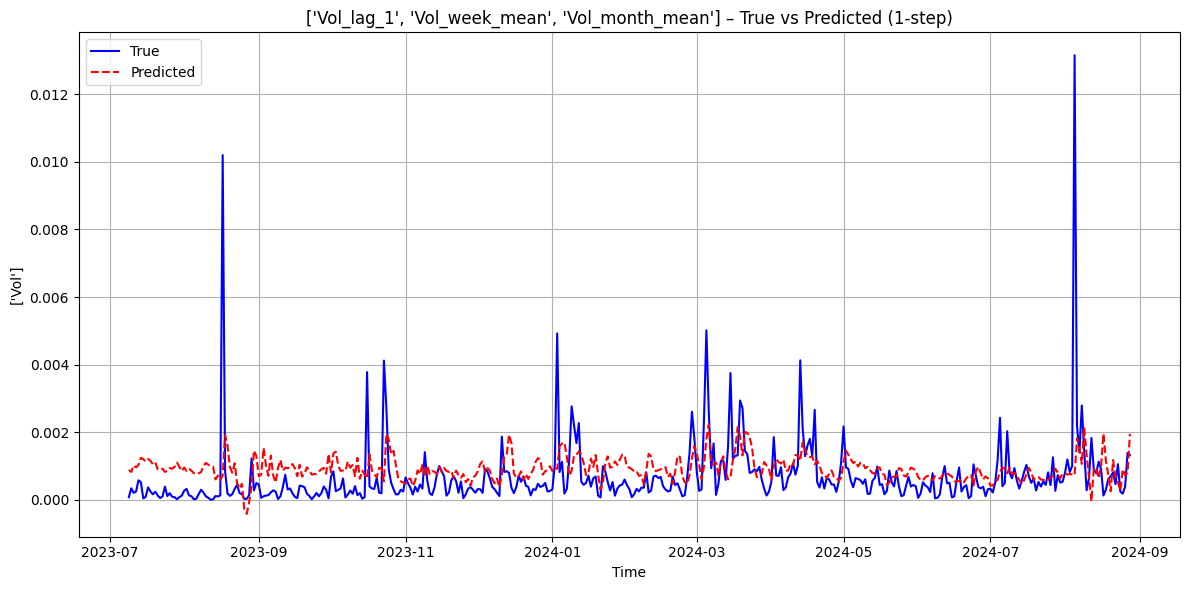

Experimento -> Lags: 2 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.142447e-06
MAE: 6.195744e-04
RMSE: 1.068853e-03
MAPE: 3.126339e+02


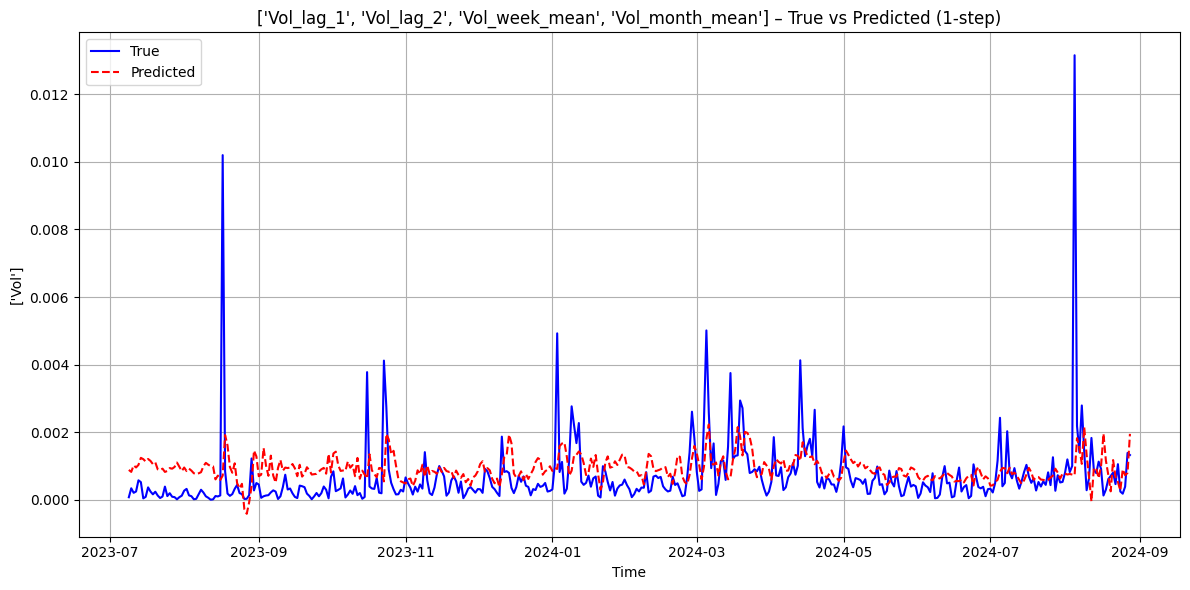

Experimento -> Lags: 3 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.142447e-06
MAE: 6.195743e-04
RMSE: 1.068853e-03
MAPE: 3.126337e+02


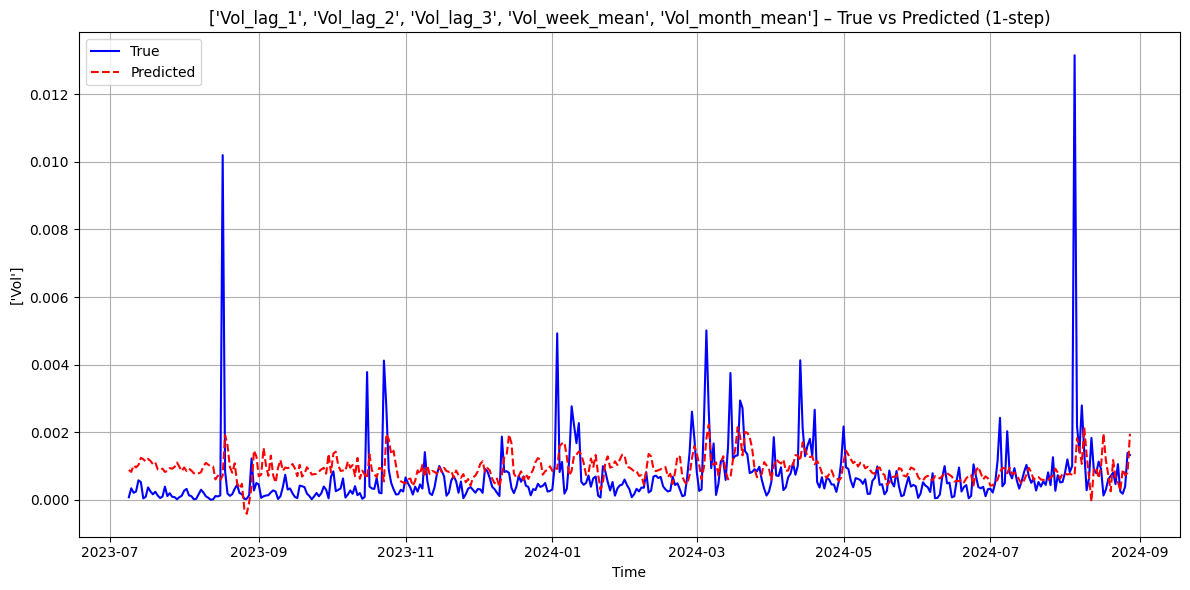

Experimento -> Lags: 4 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.142447e-06
MAE: 6.195743e-04
RMSE: 1.068853e-03
MAPE: 3.126340e+02


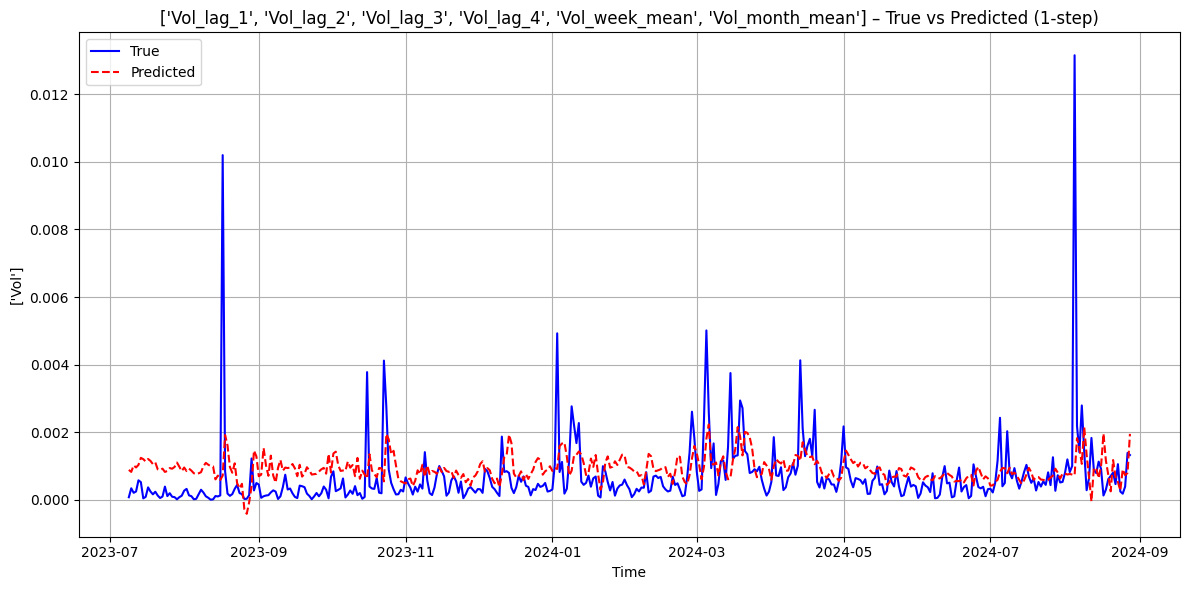

Experimento -> Lags: 5 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.143622e-06
MAE: 6.191199e-04
RMSE: 1.069403e-03
MAPE: 3.109660e+02


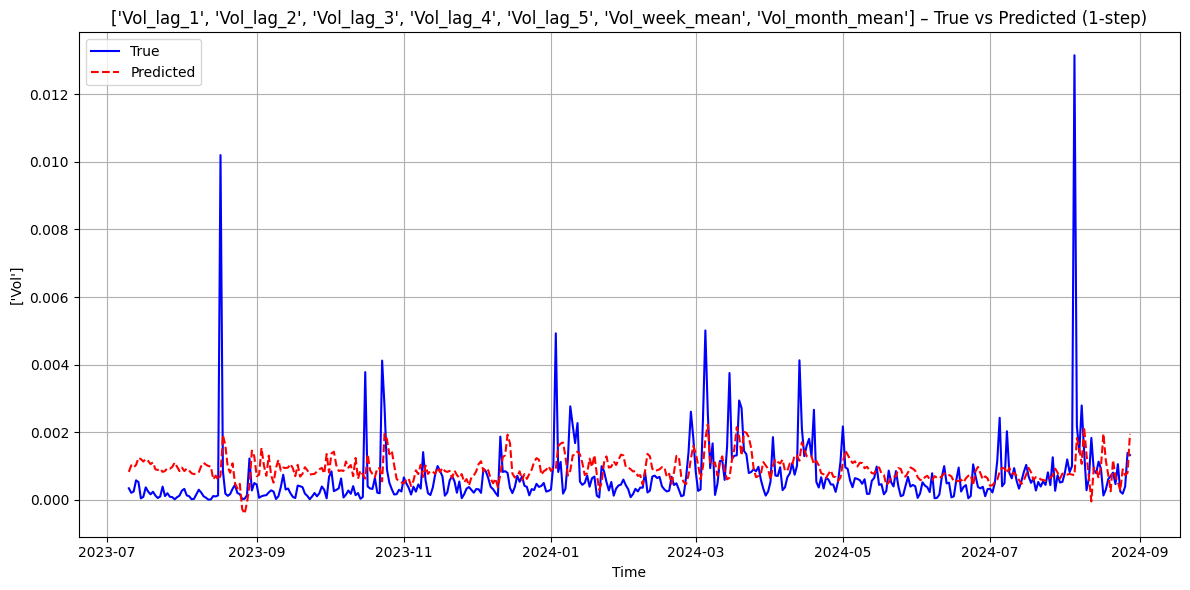

Experimento -> Lags: 6 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.143622e-06
MAE: 6.191199e-04
RMSE: 1.069403e-03
MAPE: 3.109677e+02


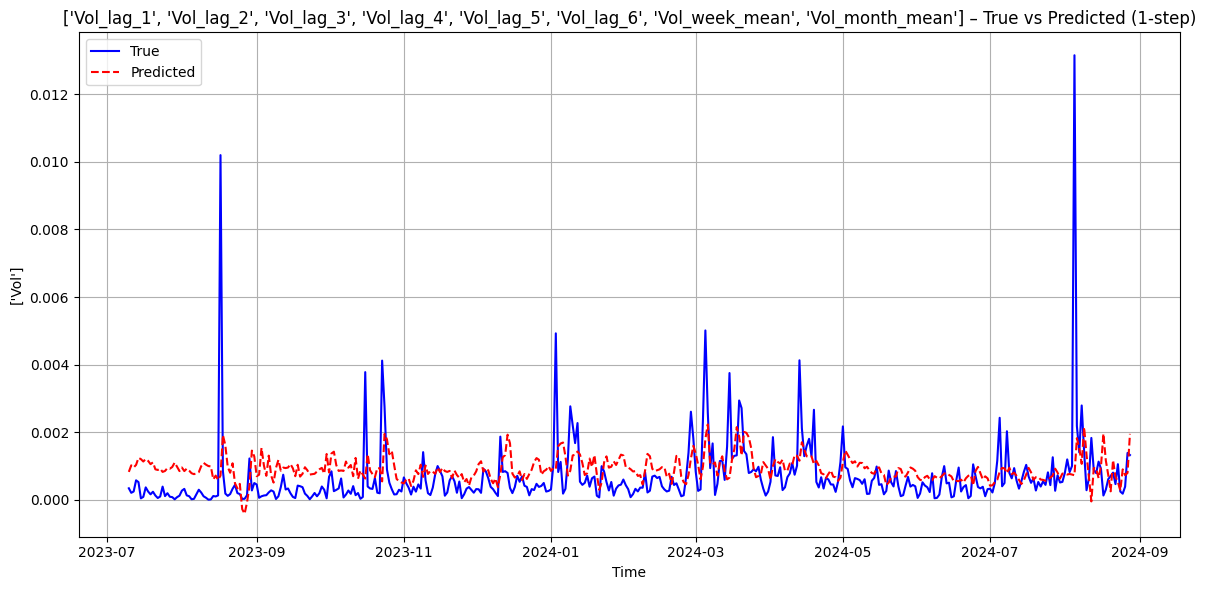

Experimento -> Lags: 7 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.143622e-06
MAE: 6.191199e-04
RMSE: 1.069403e-03
MAPE: 3.109674e+02


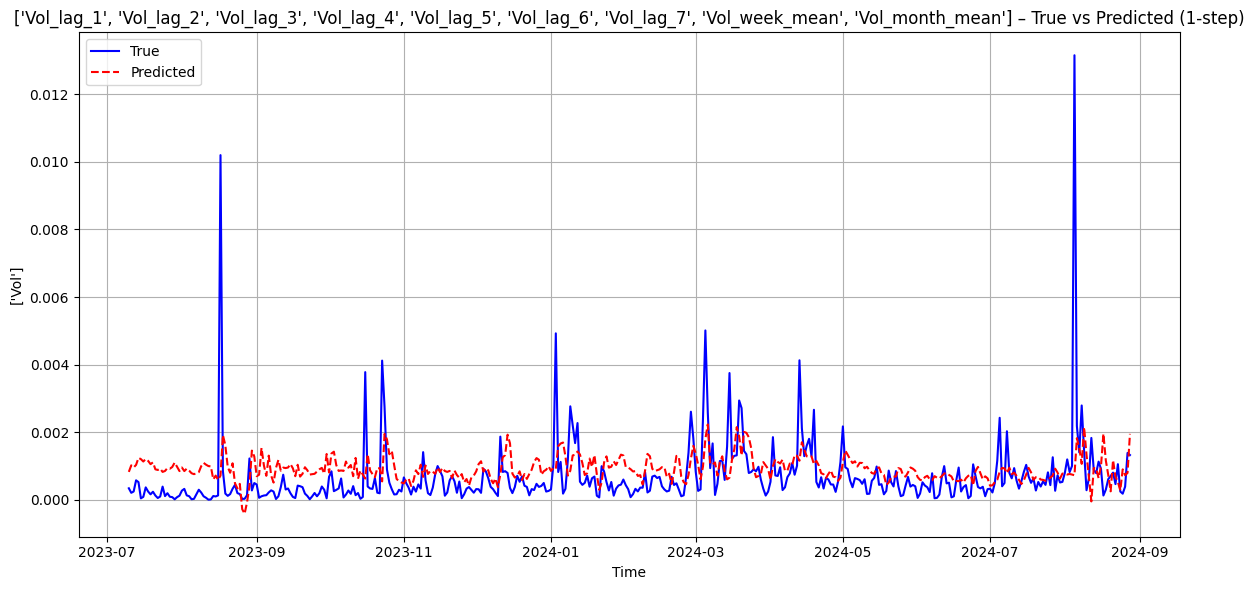

Experimento -> Lags: 8 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.143622e-06
MAE: 6.191197e-04
RMSE: 1.069403e-03
MAPE: 3.109676e+02


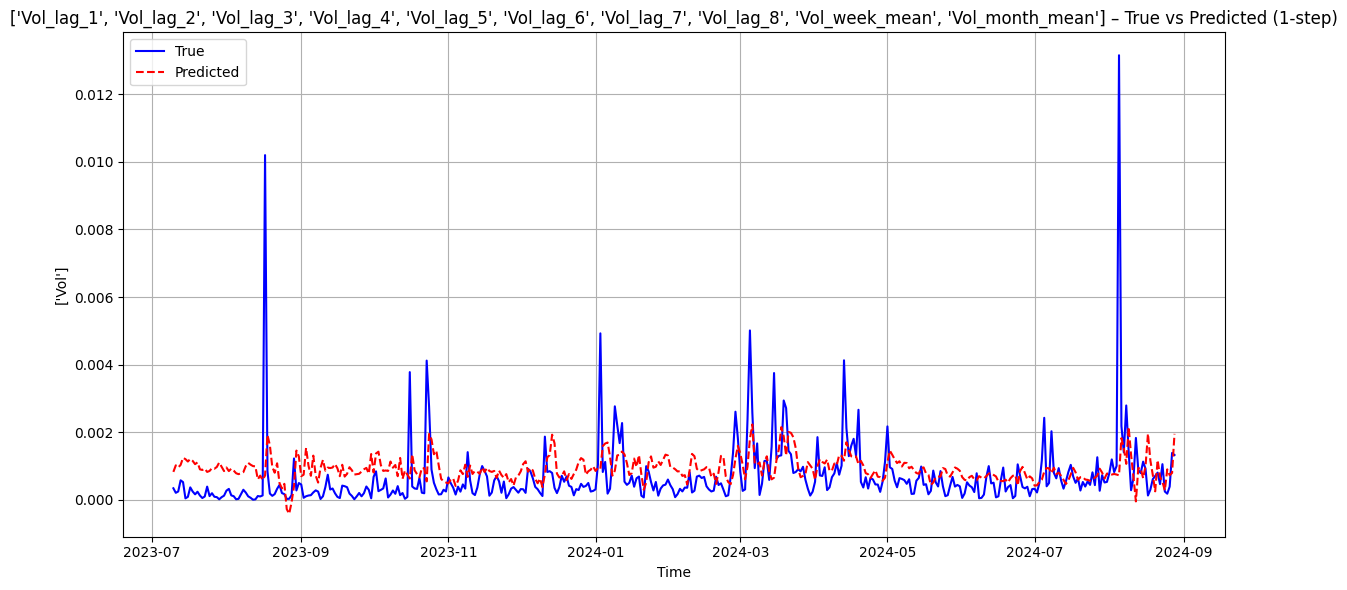

Experimento -> Lags: 9 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.143621e-06
MAE: 6.191190e-04
RMSE: 1.069402e-03
MAPE: 3.109654e+02


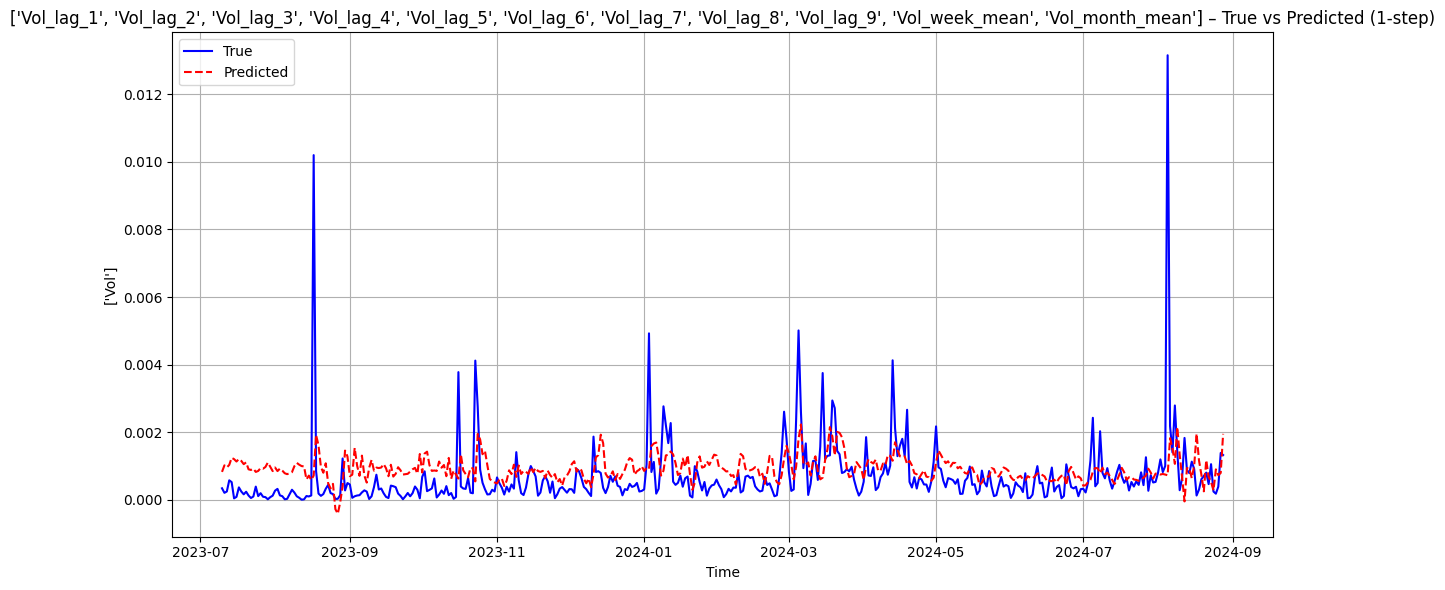

Experimento -> Lags: 10 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.145811e-06
MAE: 6.194428e-04
RMSE: 1.070426e-03
MAPE: 3.113764e+02


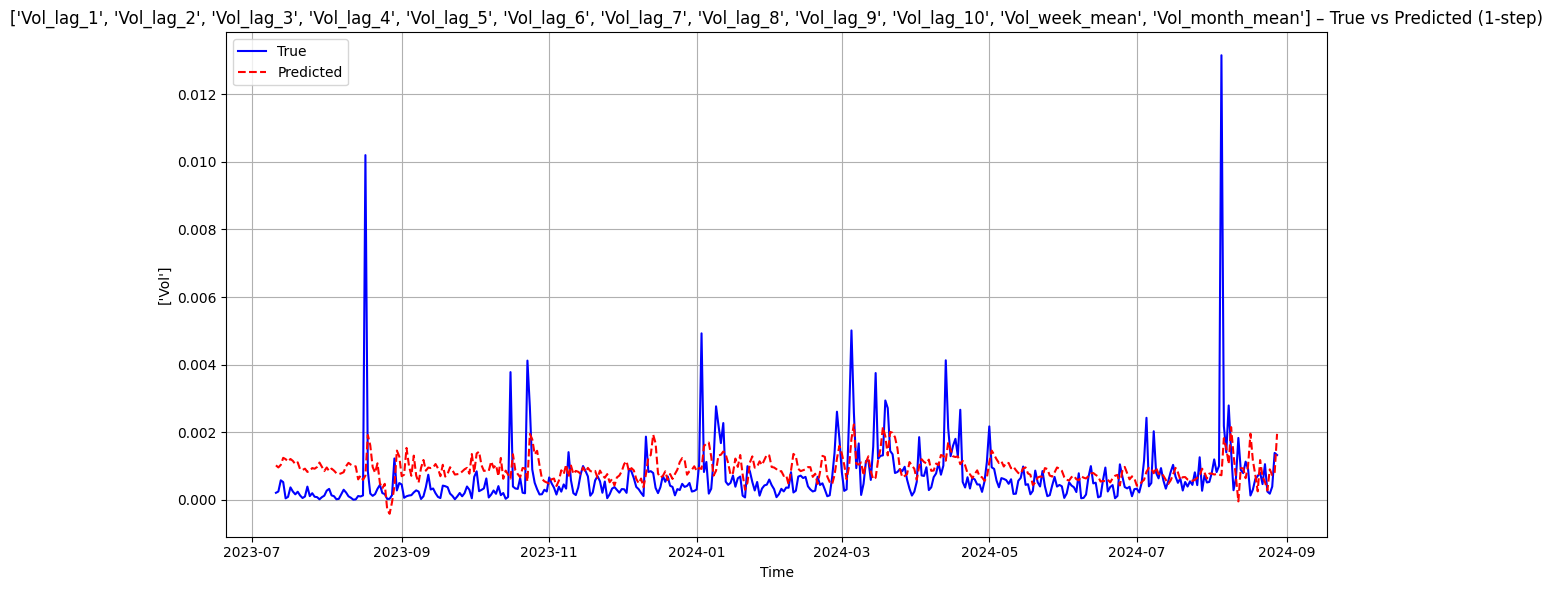

Experimento -> Lags: 11 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.145811e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113762e+02


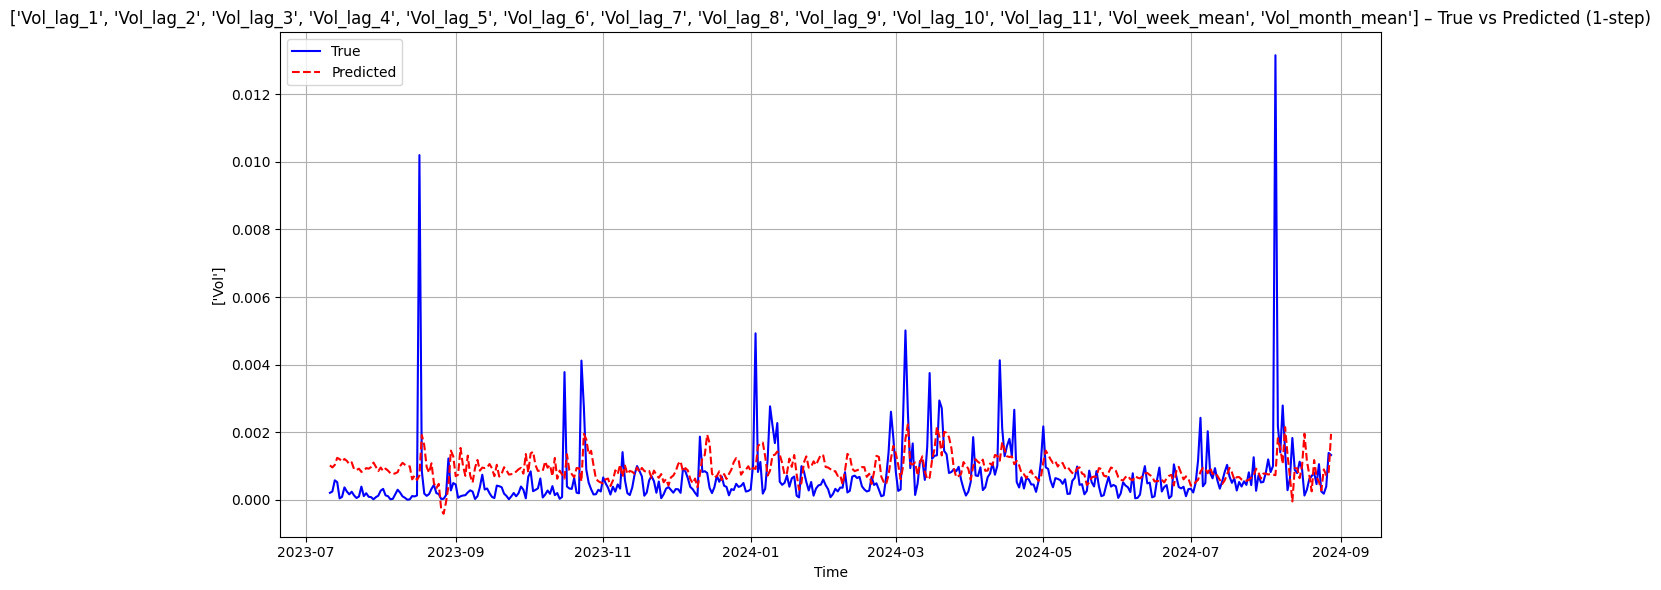

Experimento -> Lags: 12 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.145811e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113764e+02


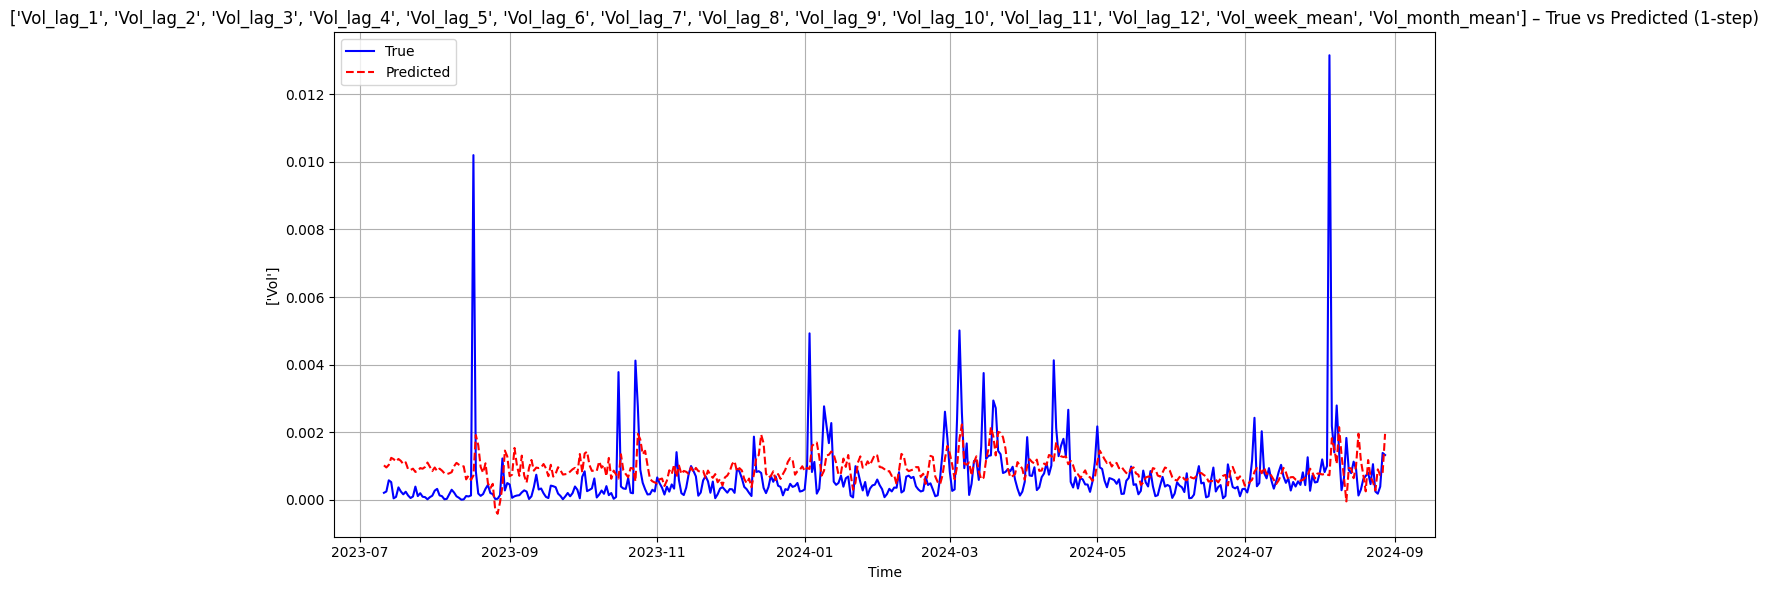

Experimento -> Lags: 13 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.145810e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113758e+02


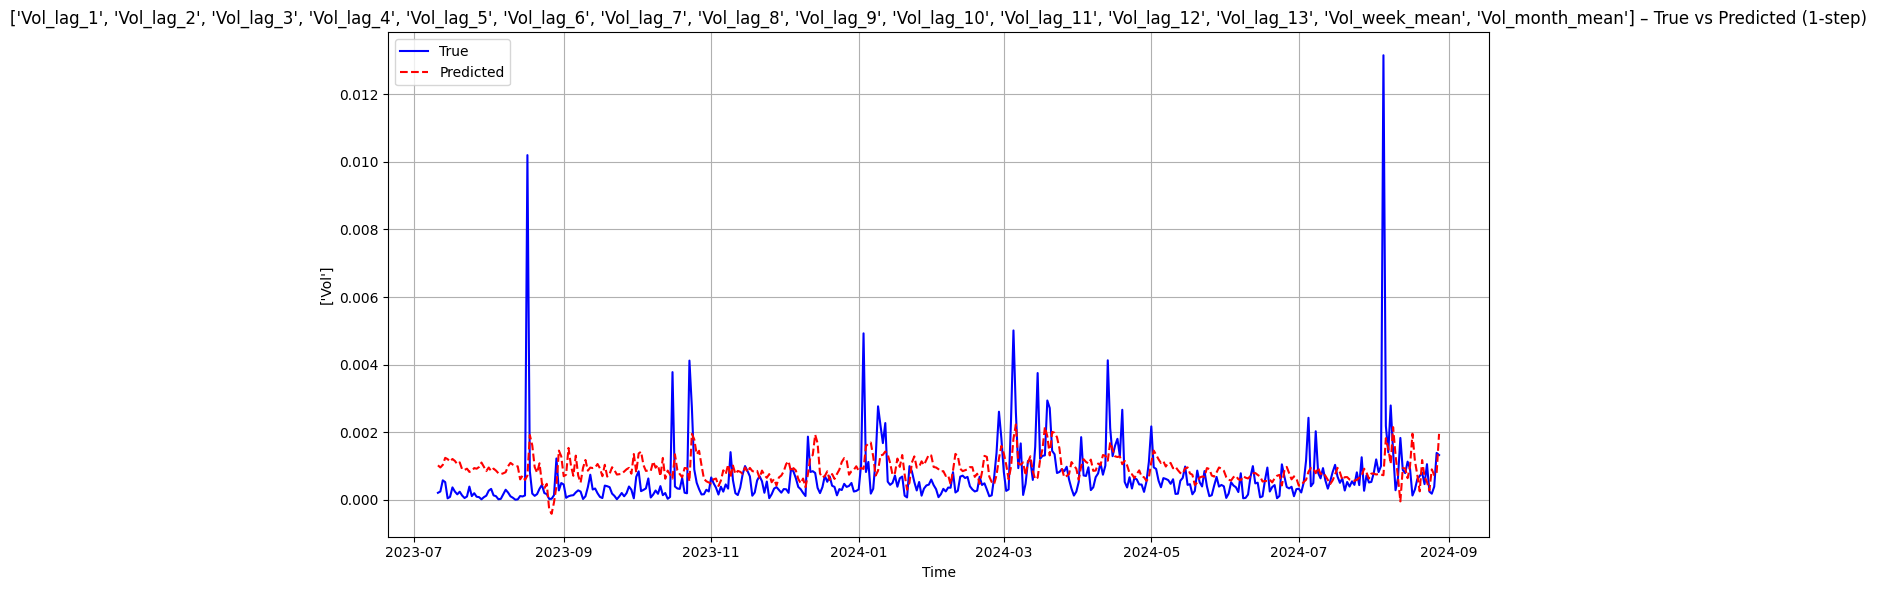

Experimento -> Lags: 14 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.145811e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113764e+02


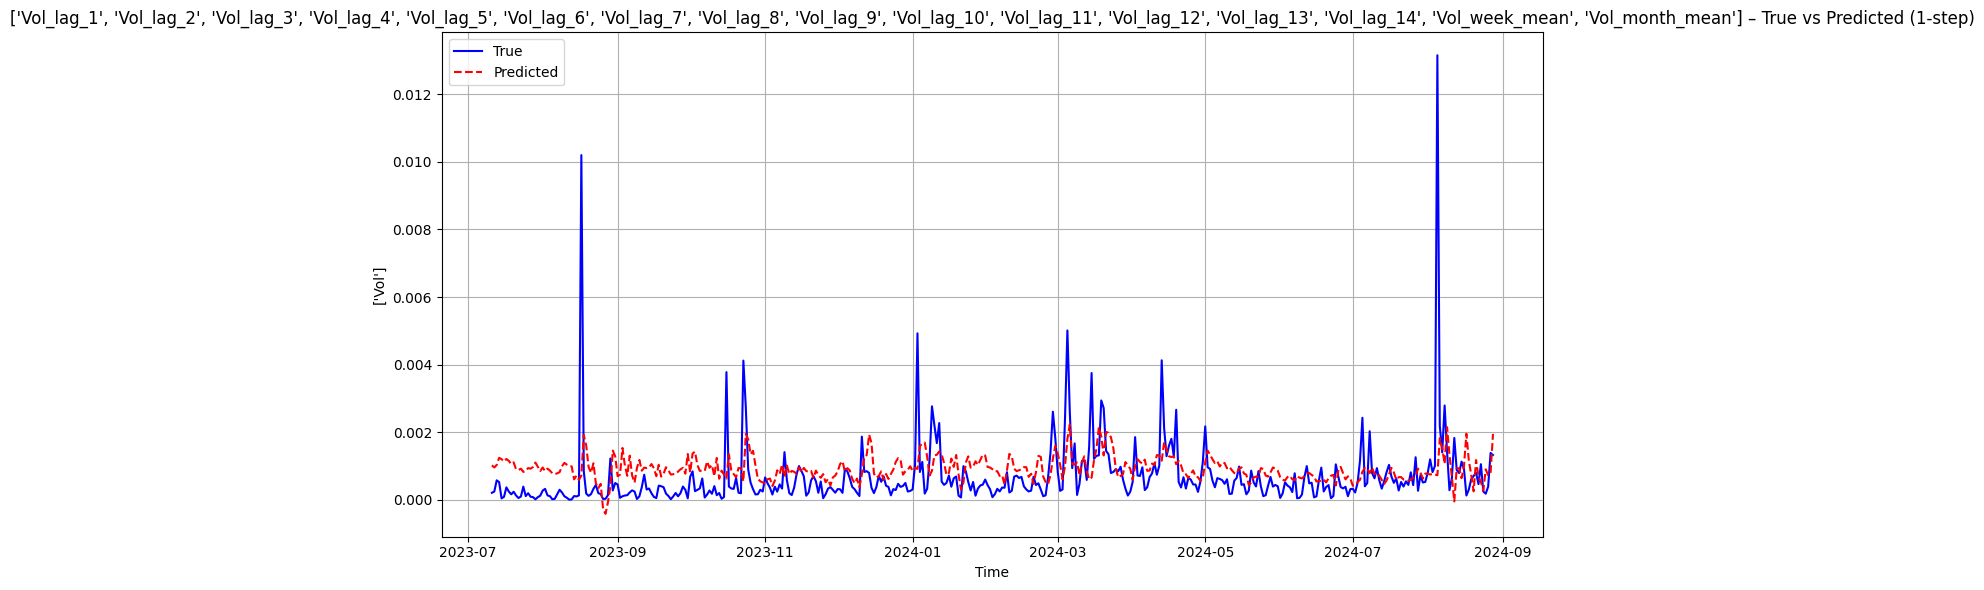

Experimento -> Lags: 15 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112022e+02


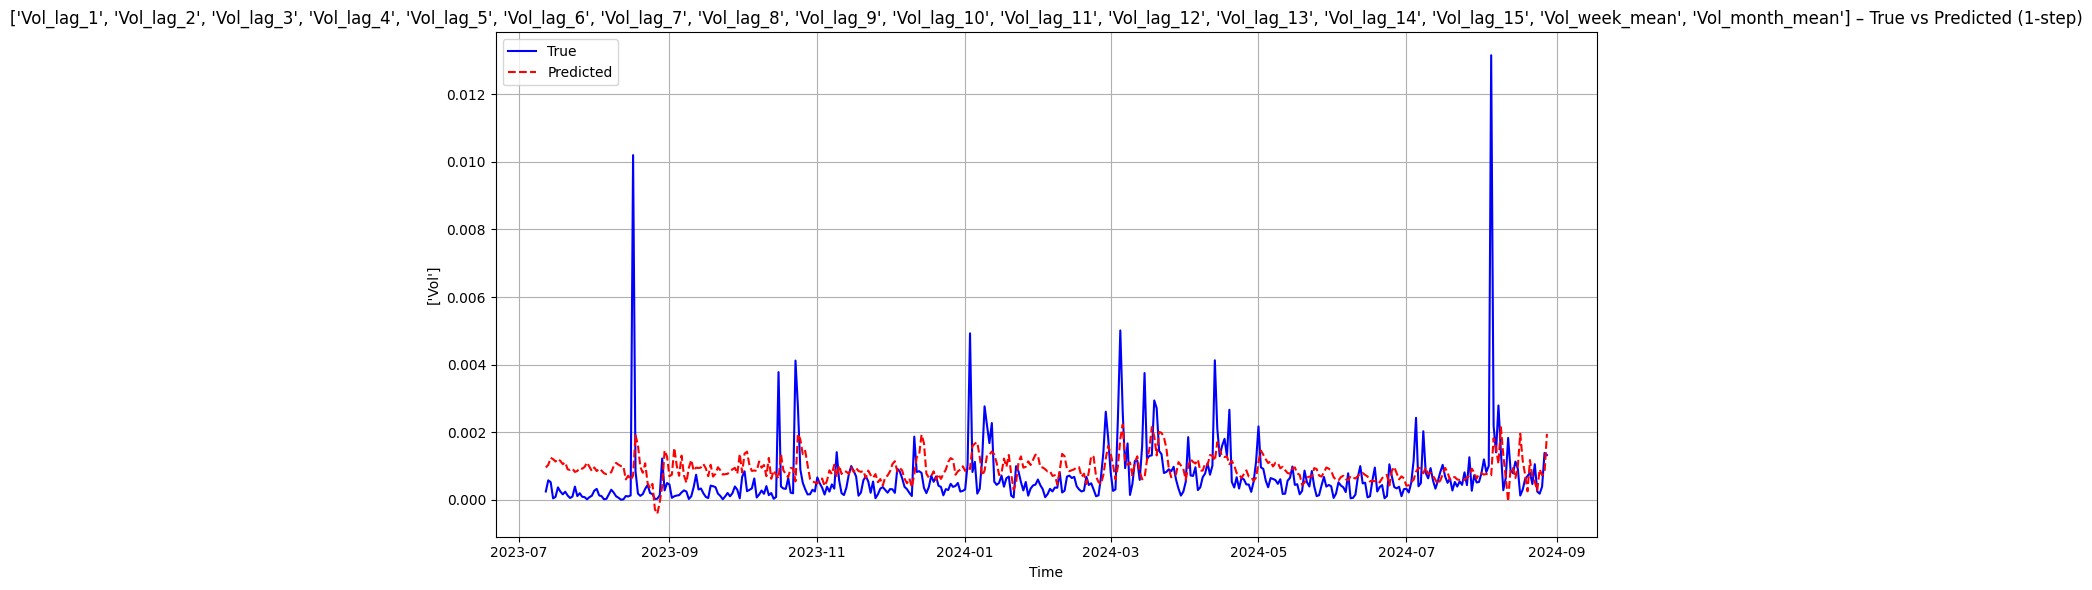

Experimento -> Lags: 16 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112032e+02


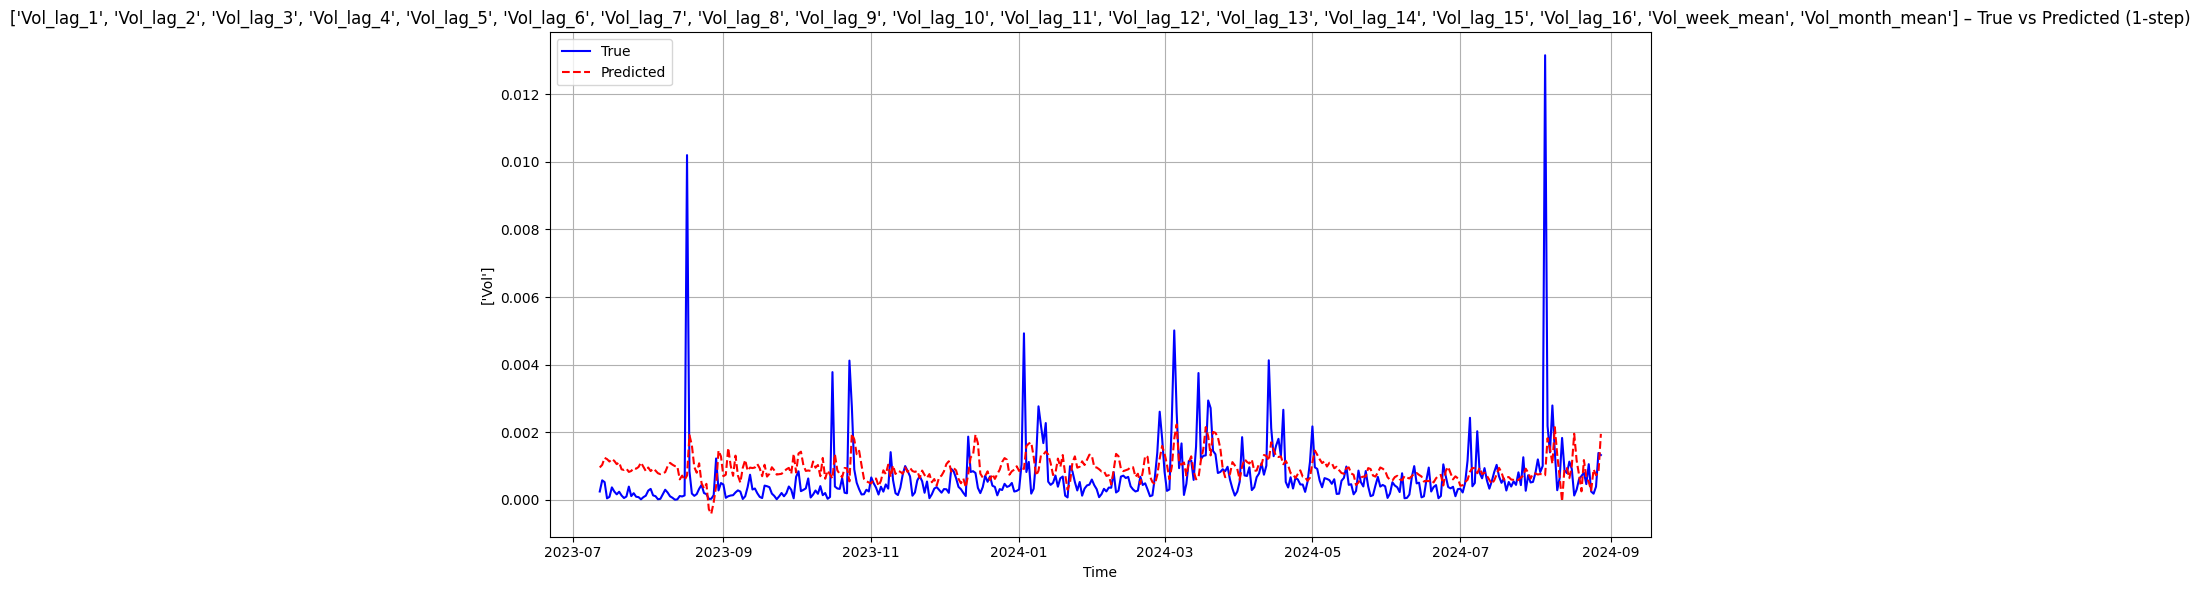

Experimento -> Lags: 17 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112032e+02


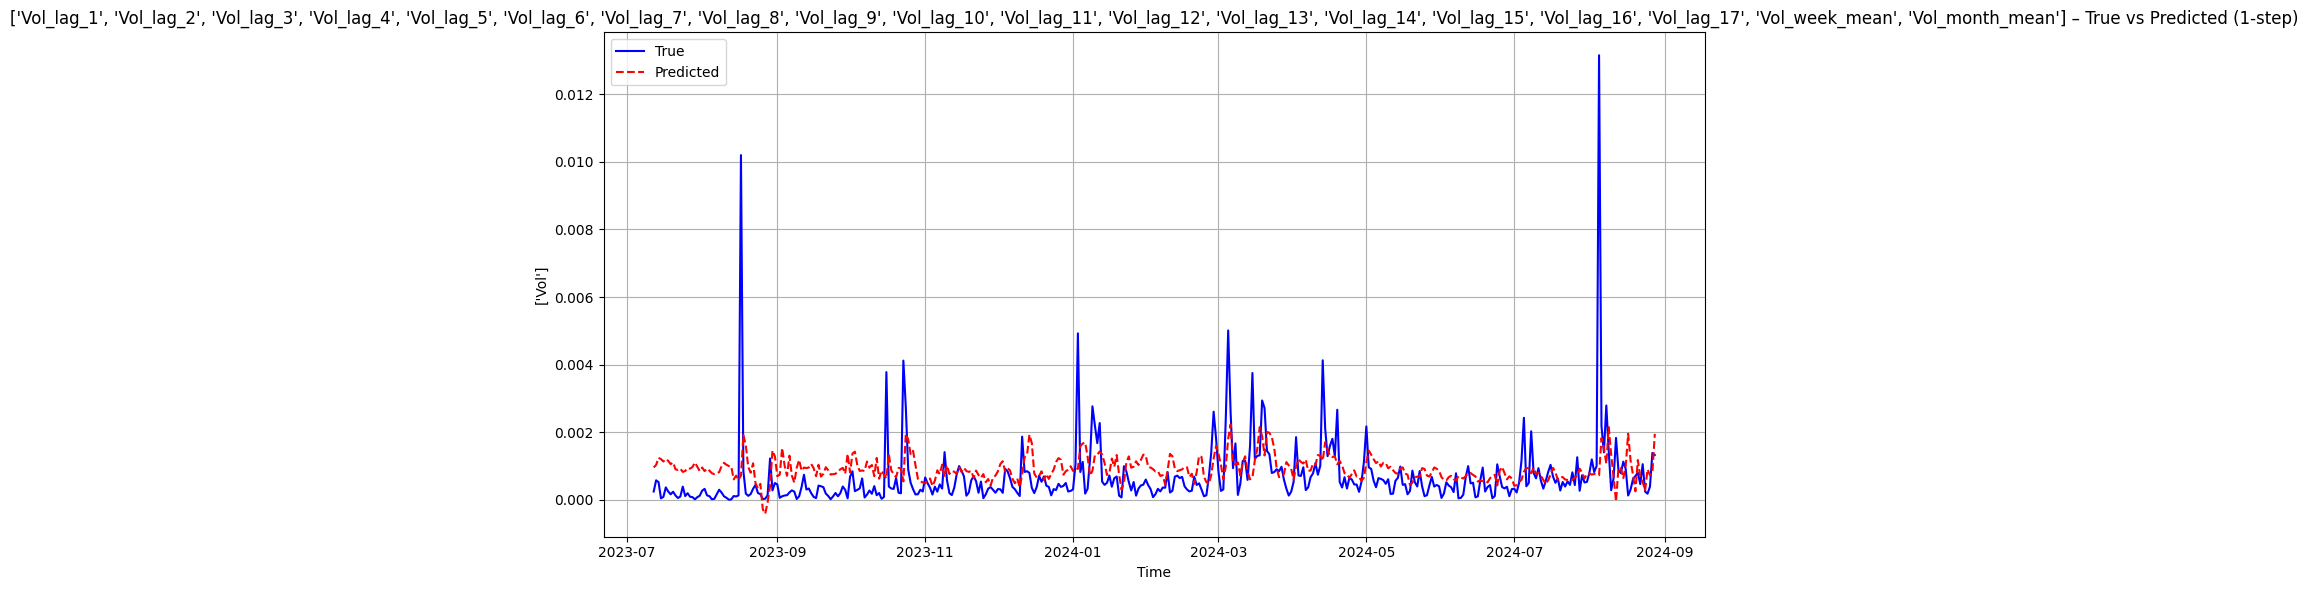

Experimento -> Lags: 18 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_lag_18', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.146987e-06
MAE: 6.189776e-04
RMSE: 1.070975e-03
MAPE: 3.112040e+02


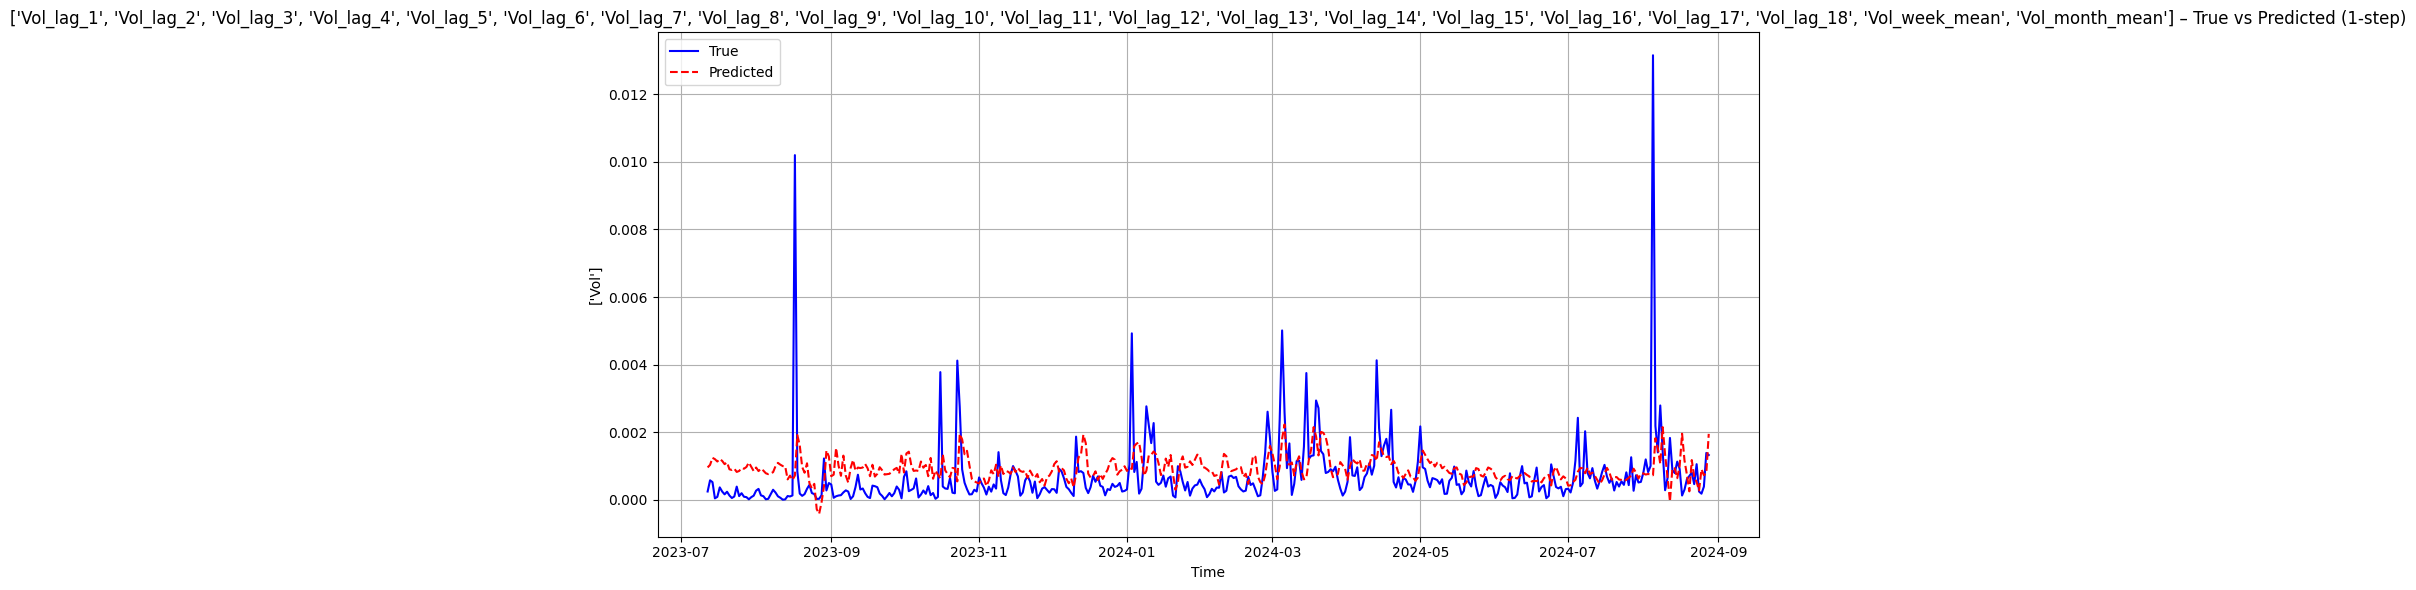

Experimento -> Lags: 19 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_lag_18', 'Vol_lag_19', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112042e+02


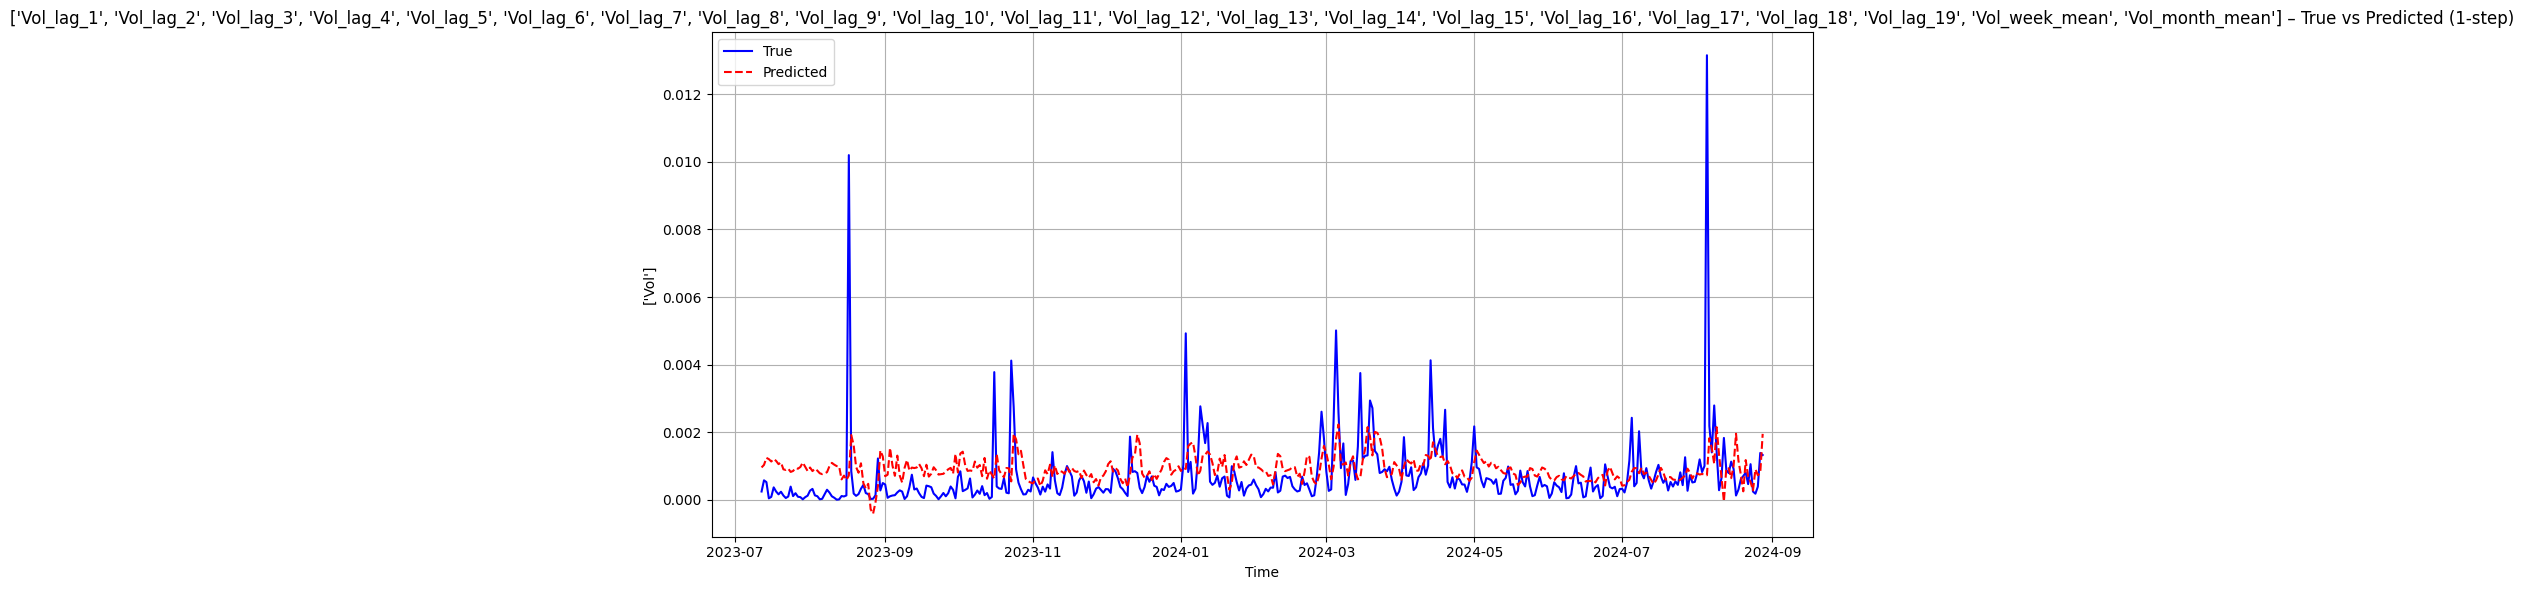

Experimento -> Lags: 20 | Use Mean Features: True
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_lag_18', 'Vol_lag_19', 'Vol_lag_20', 'Vol_week_mean', 'Vol_month_mean'] ===
MSE: 1.148540e-06
MAE: 6.187547e-04
RMSE: 1.071700e-03
MAPE: 3.112680e+02


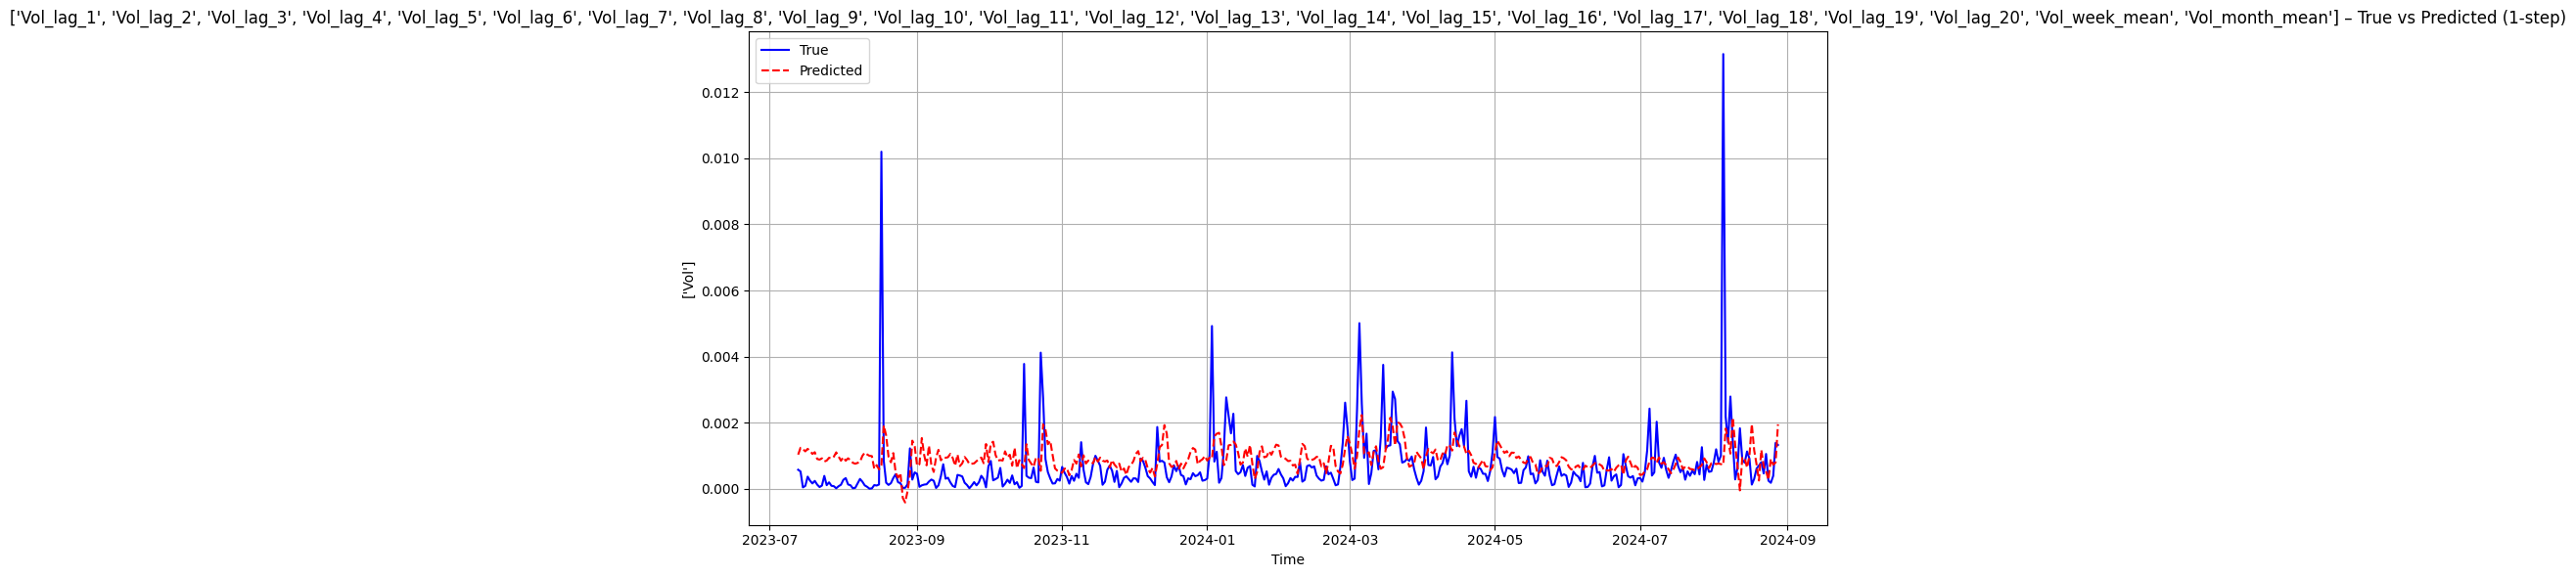

Experimento -> Lags: 1 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1'] ===
MSE: 1.142447e-06
MAE: 6.195744e-04
RMSE: 1.068853e-03
MAPE: 3.126353e+02


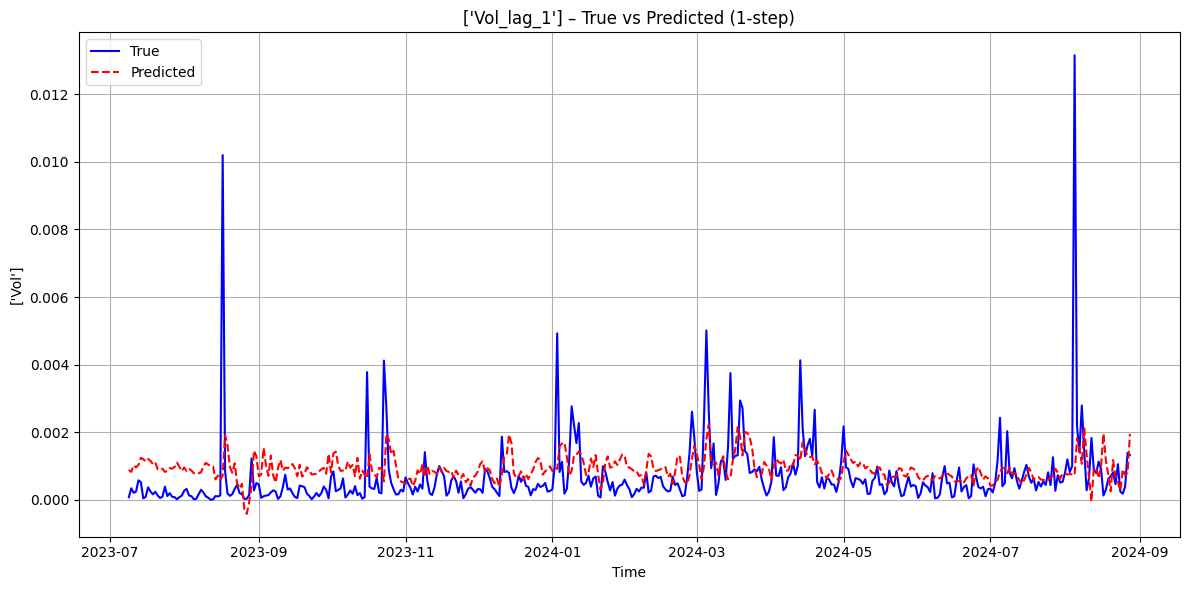

Experimento -> Lags: 2 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2'] ===
MSE: 1.142447e-06
MAE: 6.195744e-04
RMSE: 1.068853e-03
MAPE: 3.126339e+02


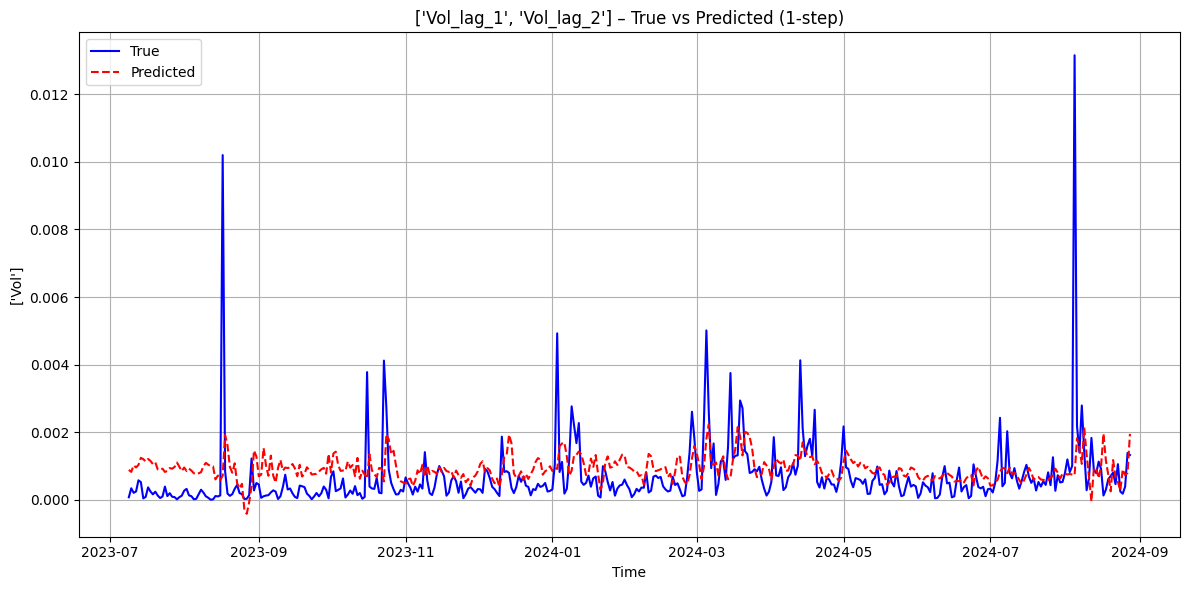

Experimento -> Lags: 3 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3'] ===
MSE: 1.142447e-06
MAE: 6.195743e-04
RMSE: 1.068853e-03
MAPE: 3.126337e+02


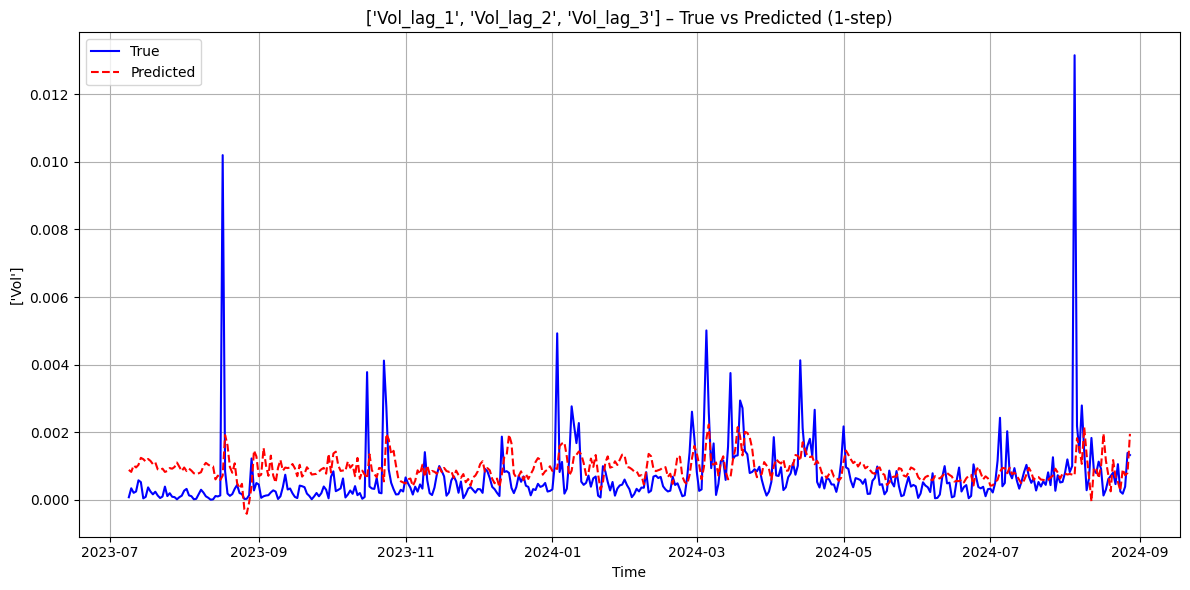

Experimento -> Lags: 4 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4'] ===
MSE: 1.142447e-06
MAE: 6.195743e-04
RMSE: 1.068853e-03
MAPE: 3.126340e+02


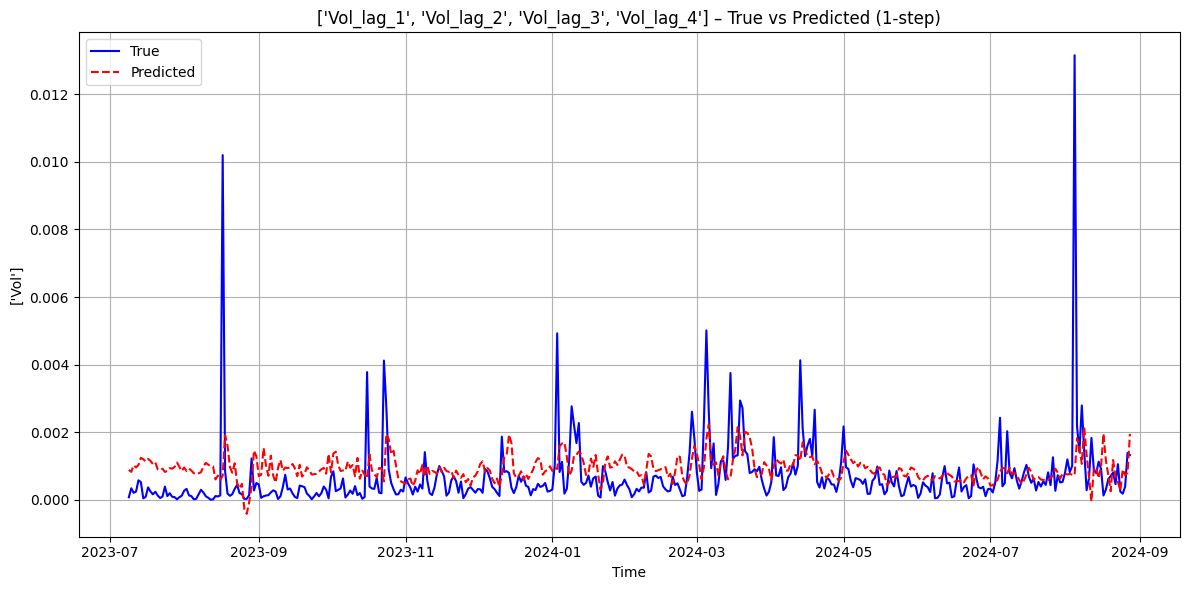

Experimento -> Lags: 5 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5'] ===
MSE: 1.143622e-06
MAE: 6.191199e-04
RMSE: 1.069403e-03
MAPE: 3.109660e+02


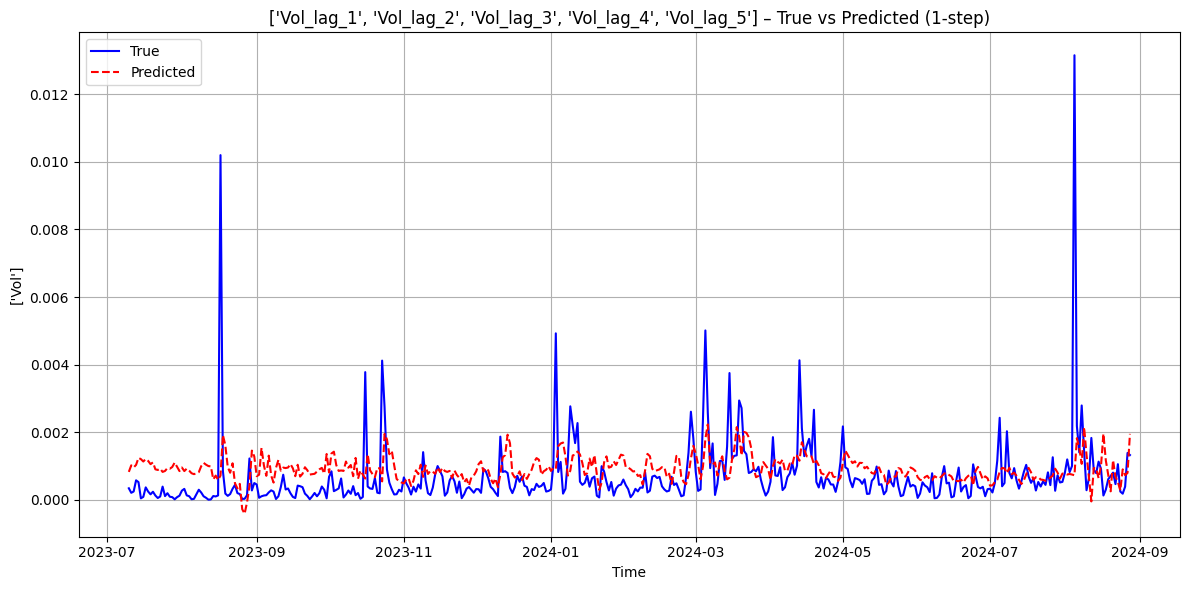

Experimento -> Lags: 6 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6'] ===
MSE: 1.143622e-06
MAE: 6.191199e-04
RMSE: 1.069403e-03
MAPE: 3.109677e+02


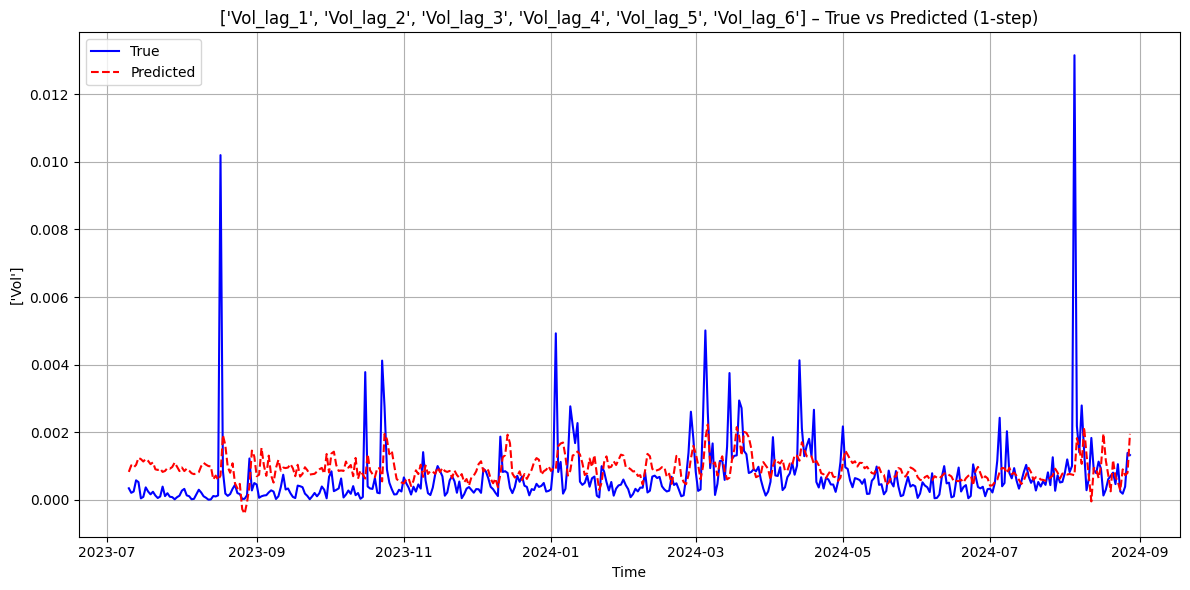

Experimento -> Lags: 7 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7'] ===
MSE: 1.143622e-06
MAE: 6.191199e-04
RMSE: 1.069403e-03
MAPE: 3.109674e+02


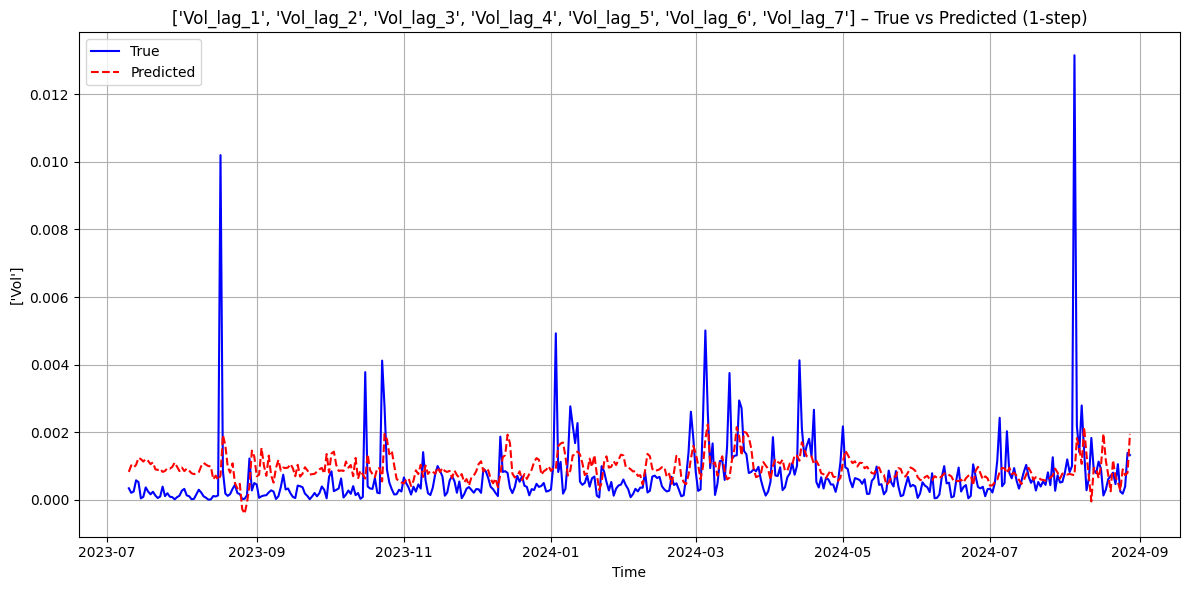

Experimento -> Lags: 8 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8'] ===
MSE: 1.143622e-06
MAE: 6.191197e-04
RMSE: 1.069403e-03
MAPE: 3.109676e+02


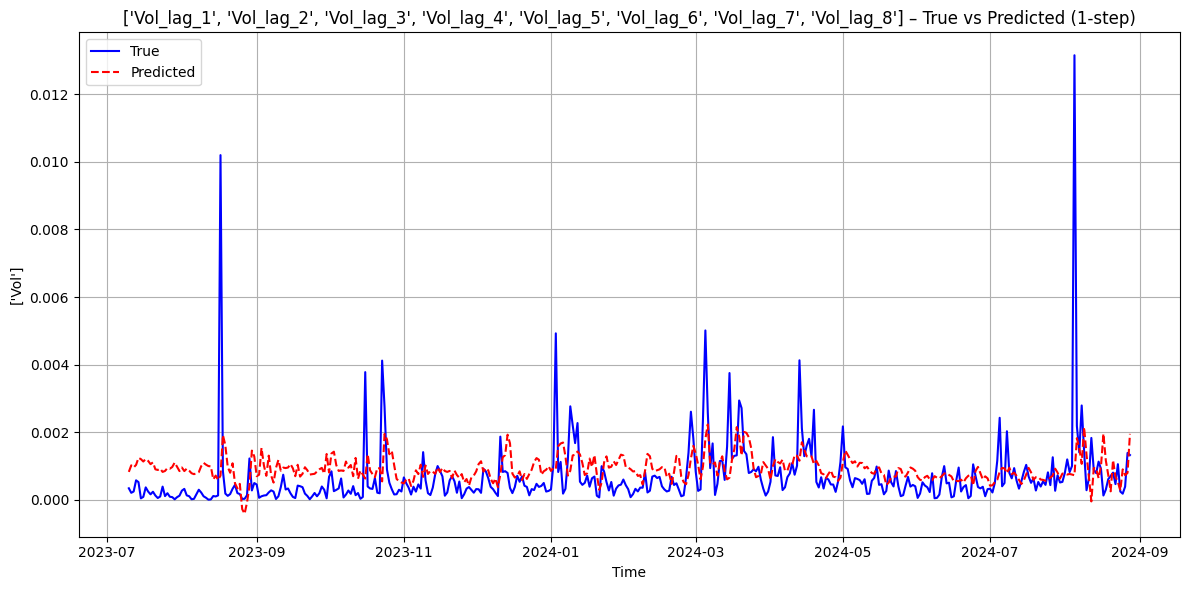

Experimento -> Lags: 9 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9'] ===
MSE: 1.143621e-06
MAE: 6.191190e-04
RMSE: 1.069402e-03
MAPE: 3.109654e+02


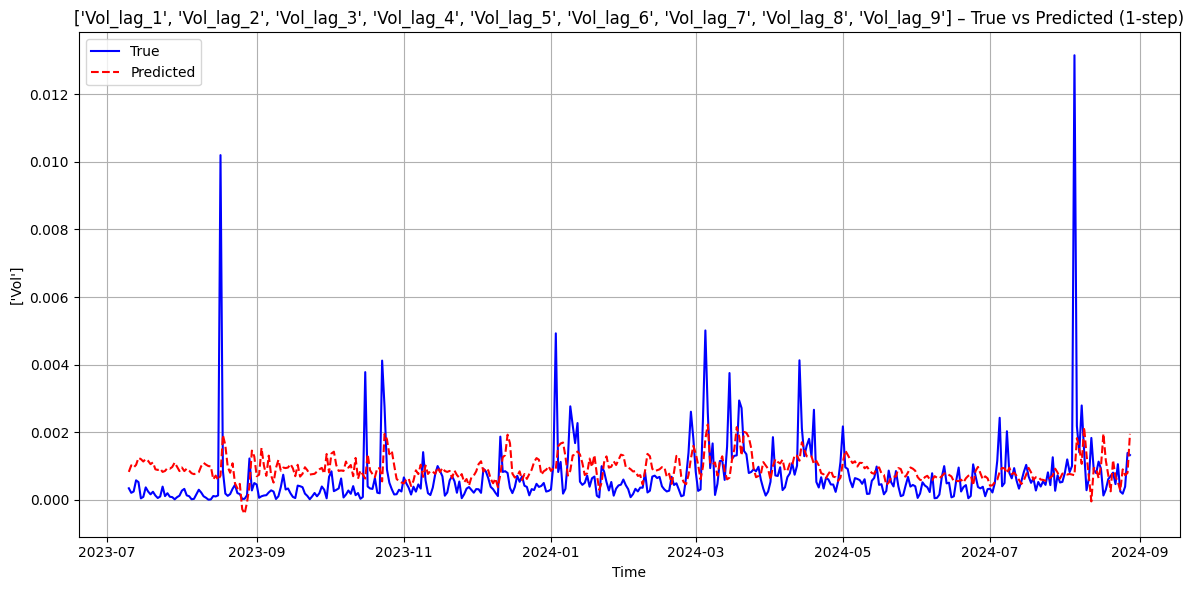

Experimento -> Lags: 10 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10'] ===
MSE: 1.145811e-06
MAE: 6.194428e-04
RMSE: 1.070426e-03
MAPE: 3.113764e+02


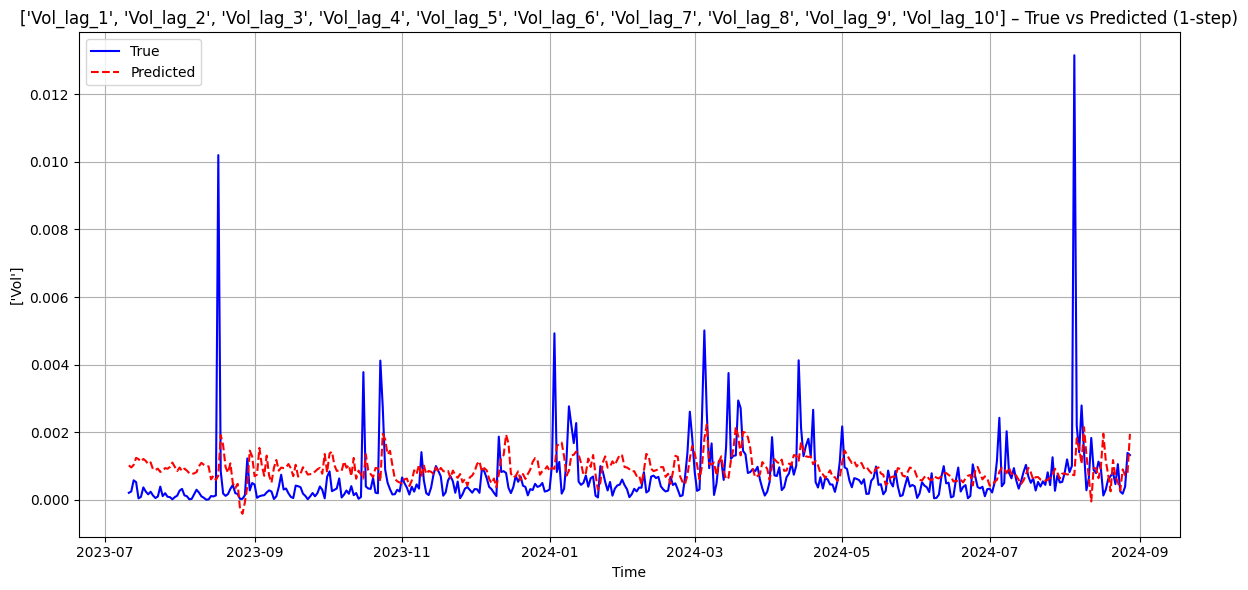

Experimento -> Lags: 11 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11'] ===
MSE: 1.145811e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113762e+02


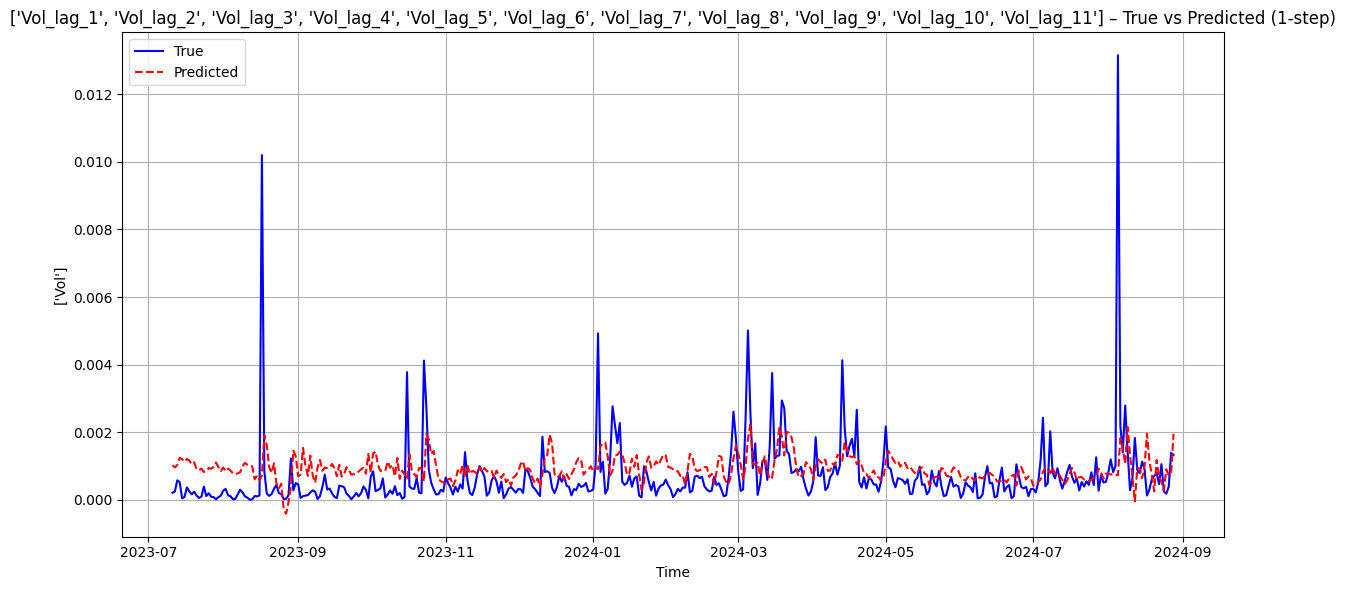

Experimento -> Lags: 12 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12'] ===
MSE: 1.145811e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113764e+02


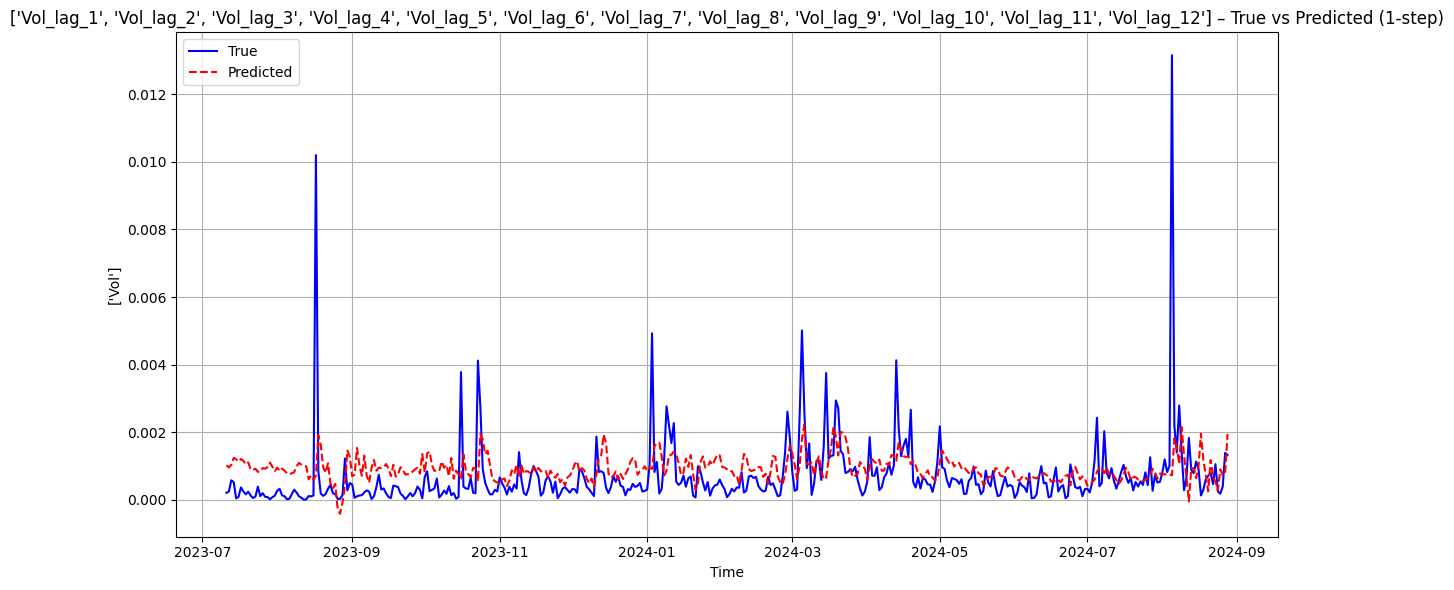

Experimento -> Lags: 13 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13'] ===
MSE: 1.145810e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113758e+02


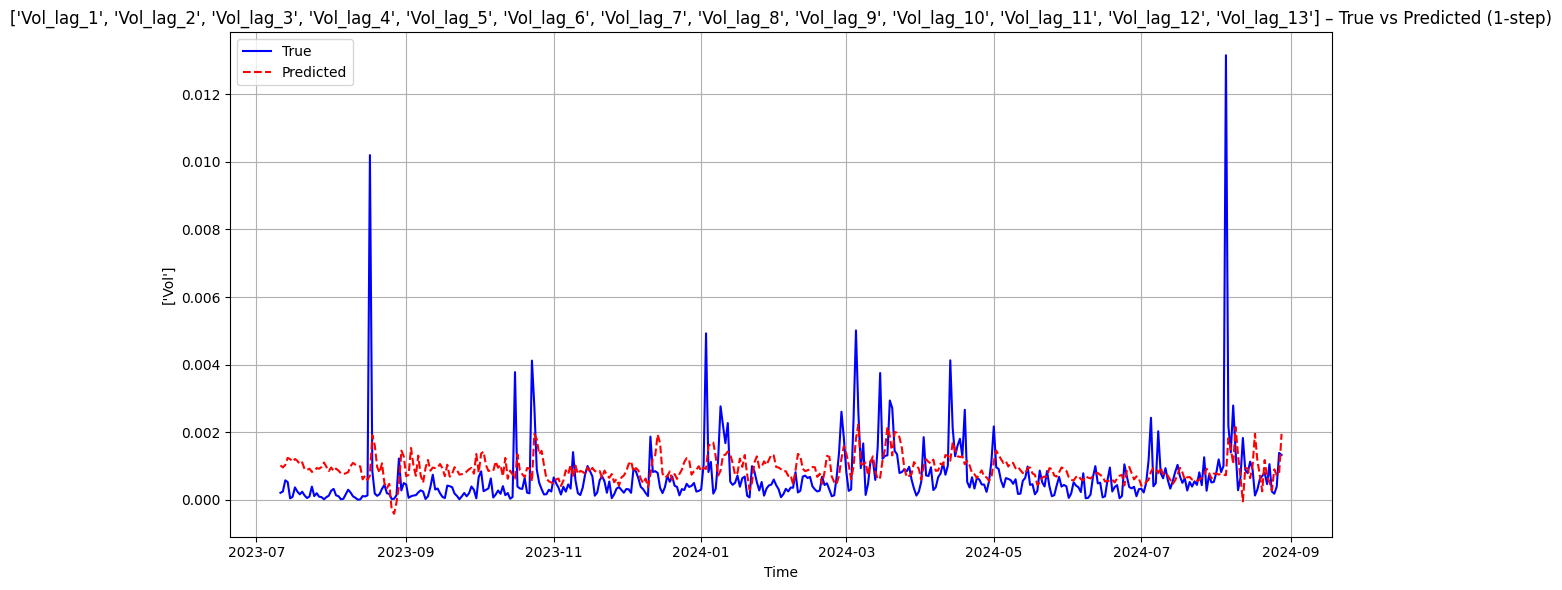

Experimento -> Lags: 14 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14'] ===
MSE: 1.145811e-06
MAE: 6.194421e-04
RMSE: 1.070425e-03
MAPE: 3.113764e+02


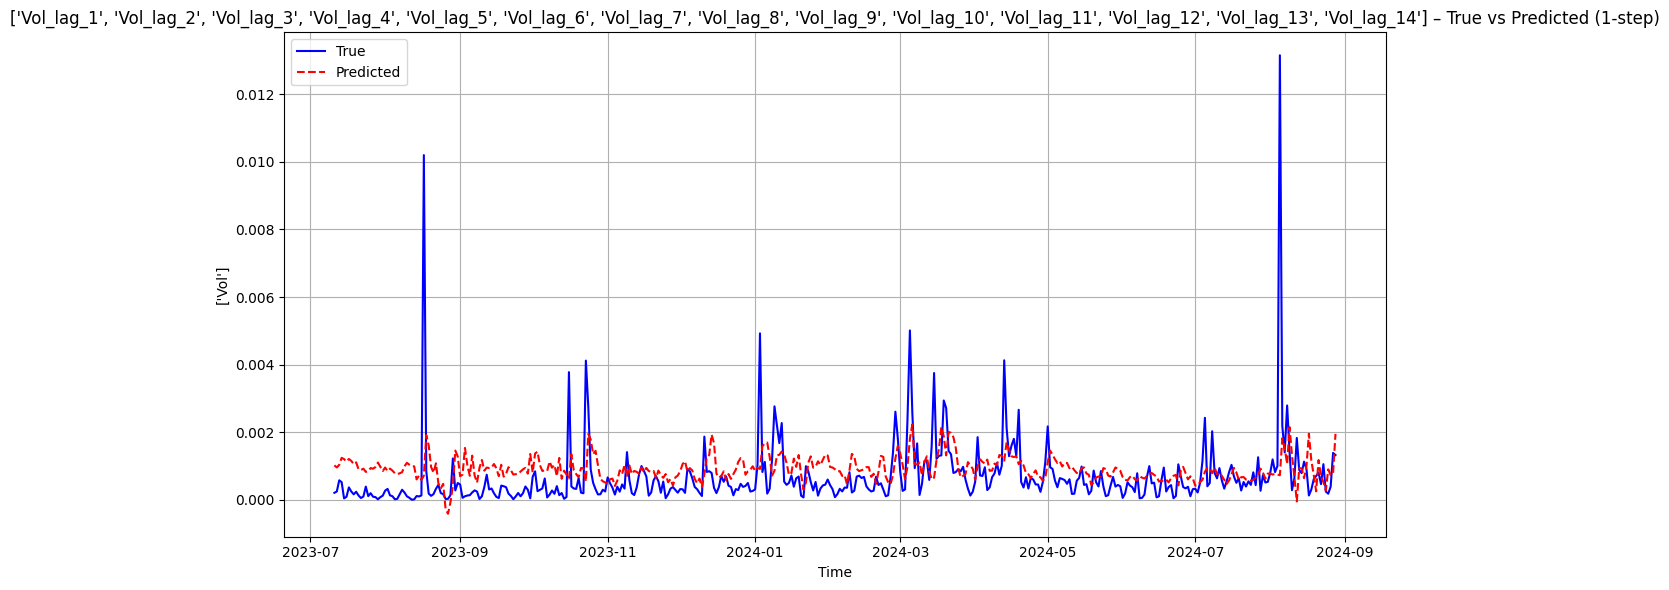

Experimento -> Lags: 15 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112022e+02


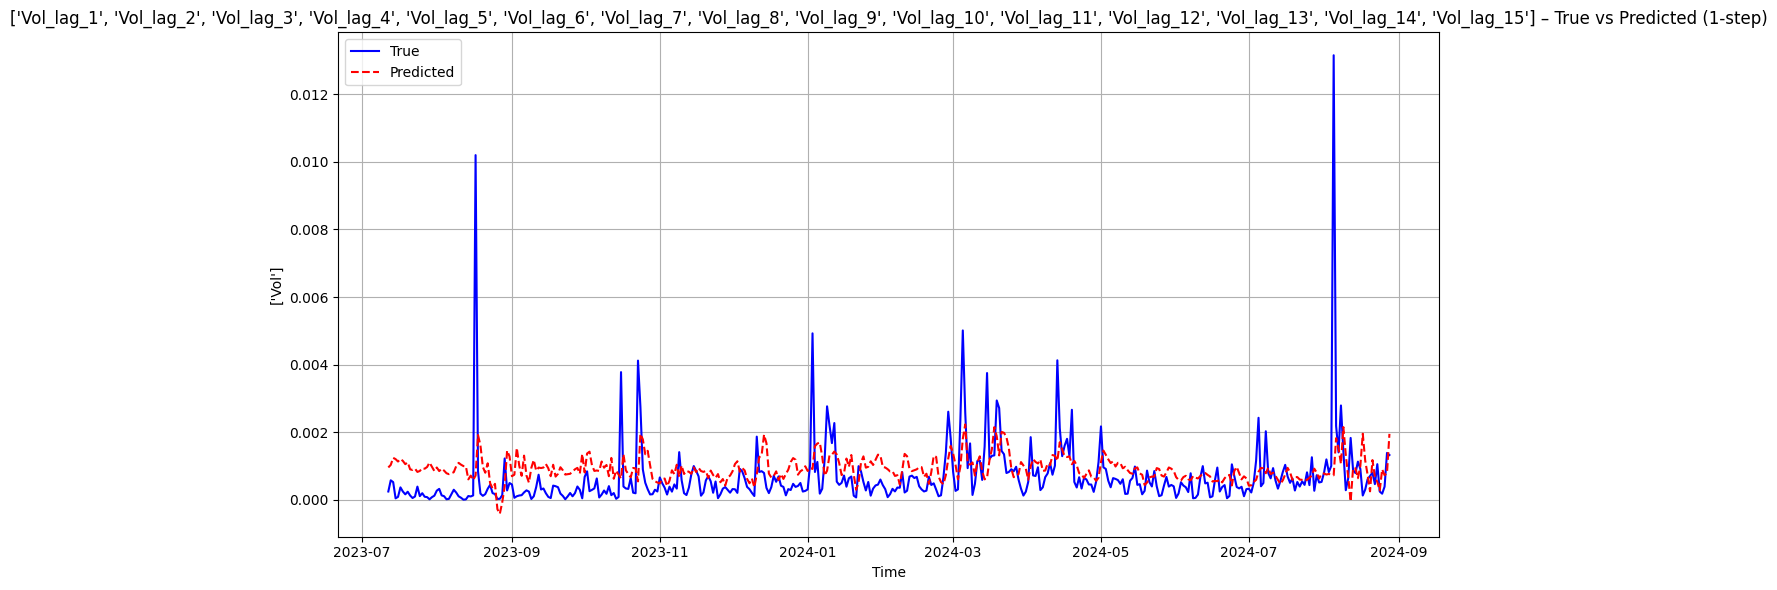

Experimento -> Lags: 16 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112032e+02


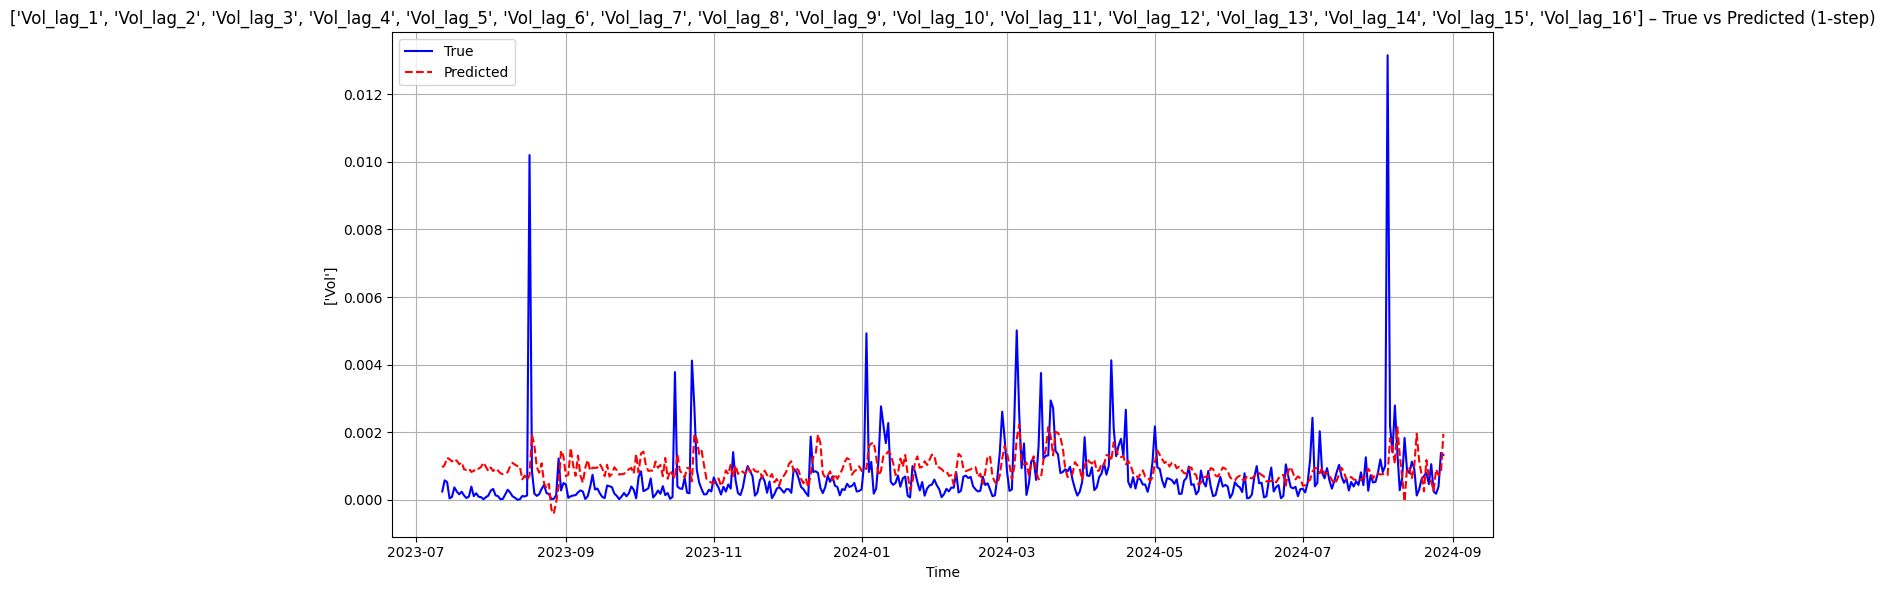

Experimento -> Lags: 17 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112032e+02


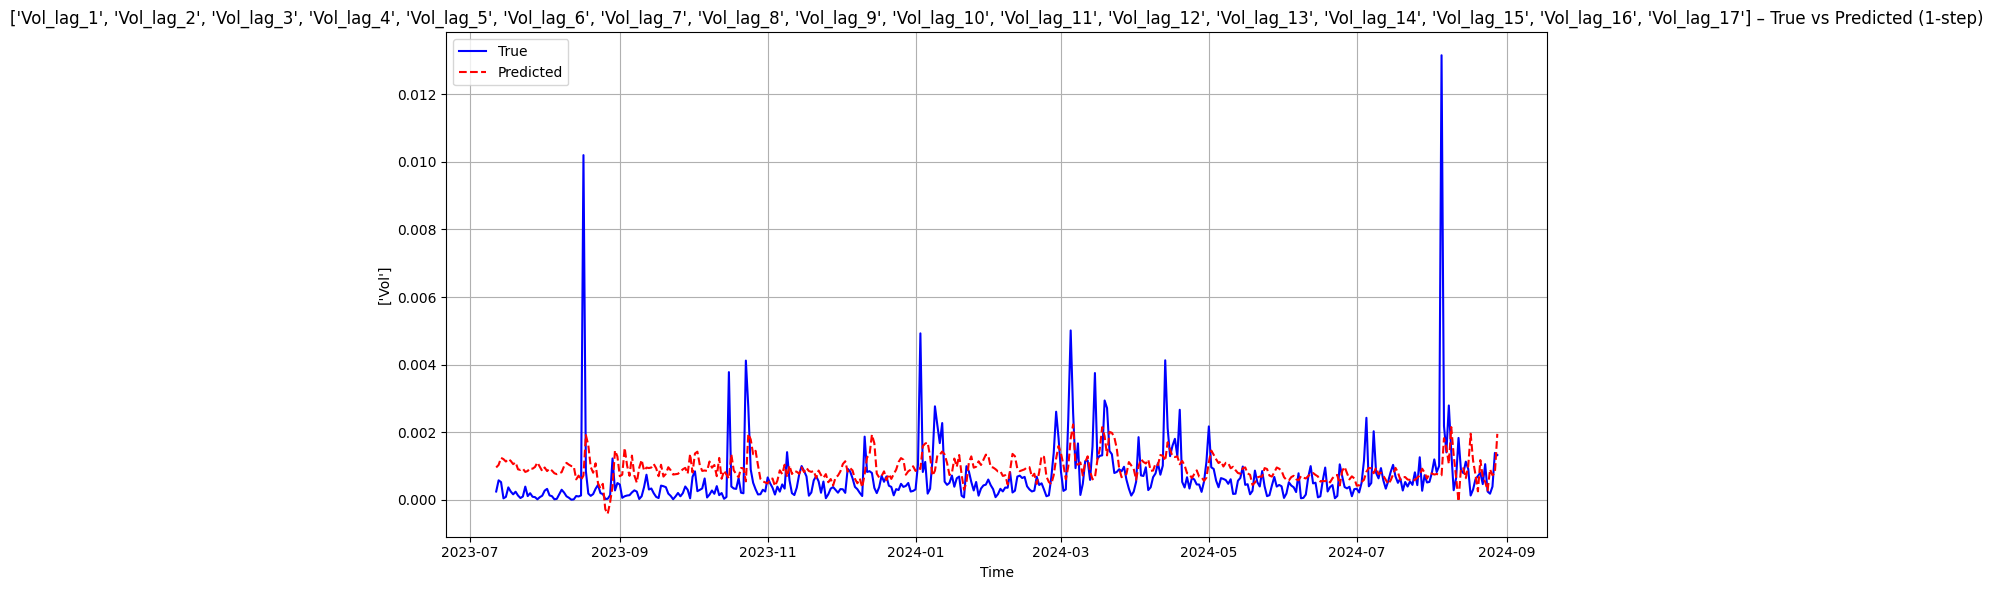

Experimento -> Lags: 18 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_lag_18'] ===
MSE: 1.146987e-06
MAE: 6.189776e-04
RMSE: 1.070975e-03
MAPE: 3.112040e+02


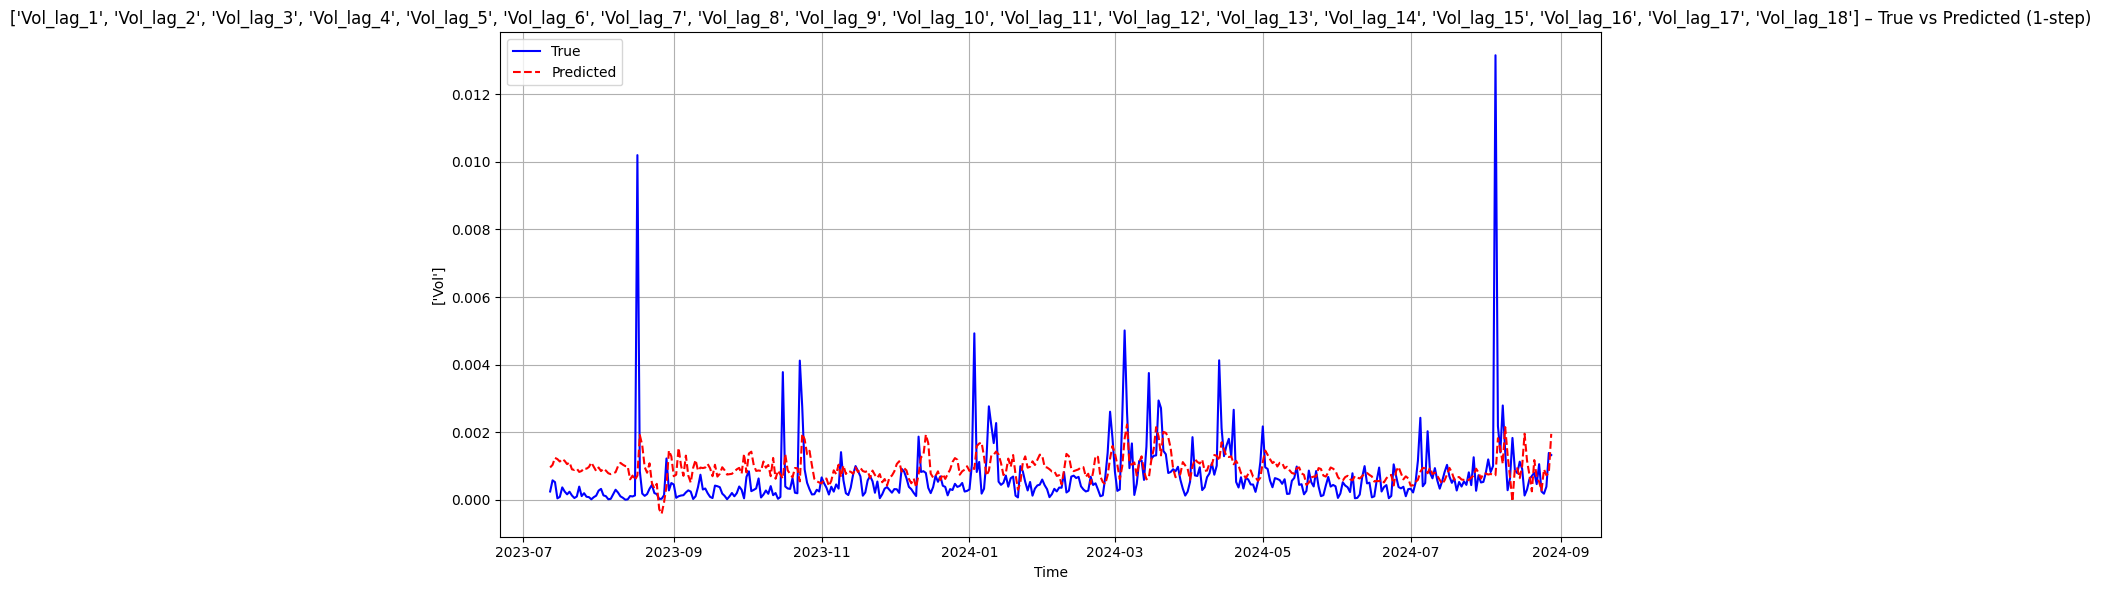

Experimento -> Lags: 19 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_lag_18', 'Vol_lag_19'] ===
MSE: 1.146987e-06
MAE: 6.189775e-04
RMSE: 1.070975e-03
MAPE: 3.112042e+02


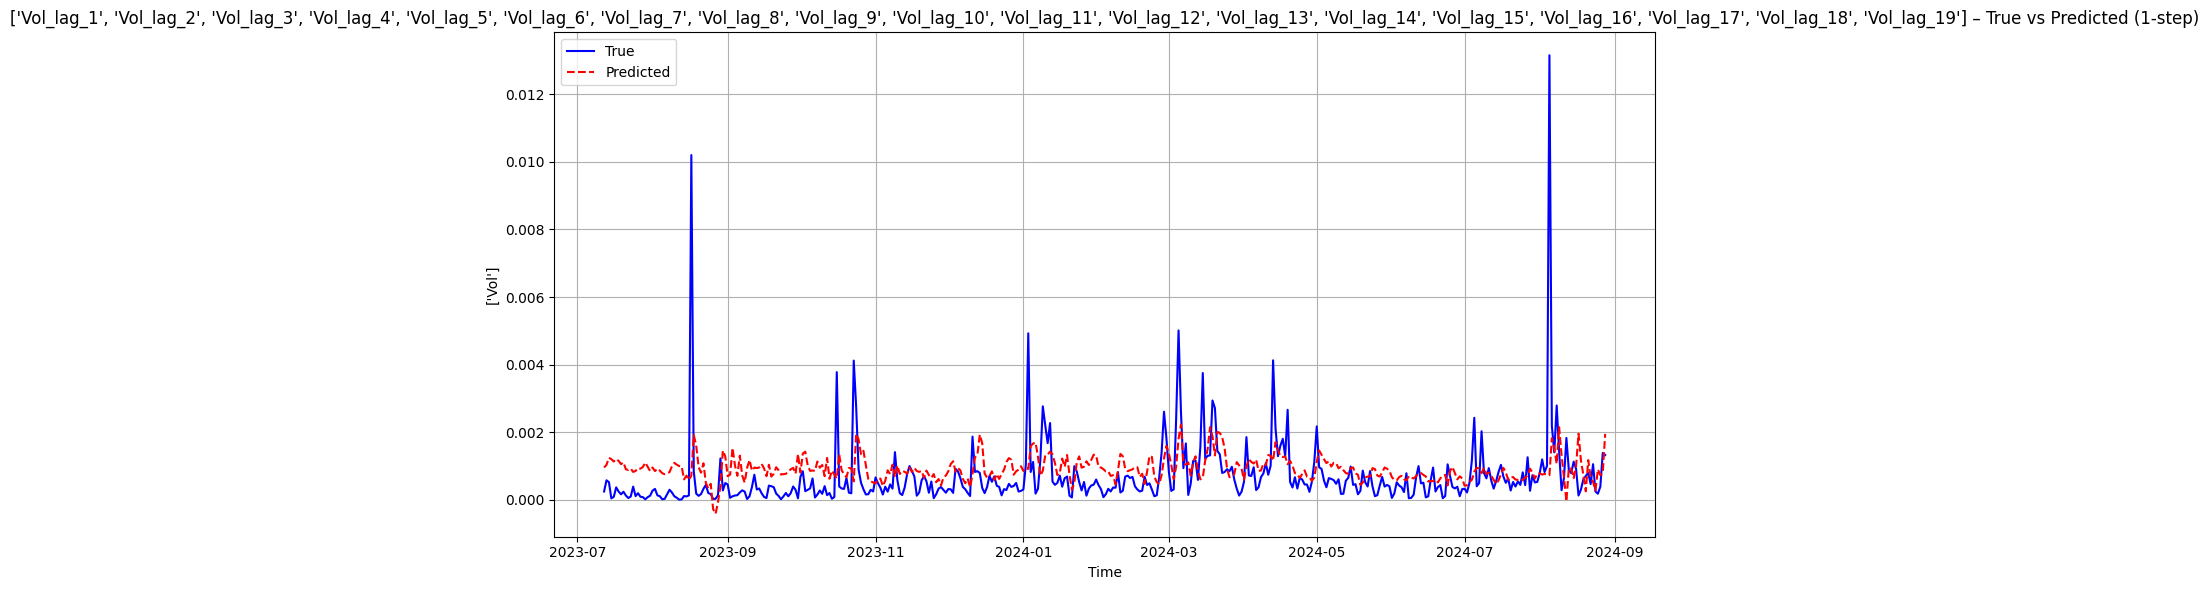

Experimento -> Lags: 20 | Use Mean Features: False
Calculando features de volatilidade



=== ['Vol_lag_1', 'Vol_lag_2', 'Vol_lag_3', 'Vol_lag_4', 'Vol_lag_5', 'Vol_lag_6', 'Vol_lag_7', 'Vol_lag_8', 'Vol_lag_9', 'Vol_lag_10', 'Vol_lag_11', 'Vol_lag_12', 'Vol_lag_13', 'Vol_lag_14', 'Vol_lag_15', 'Vol_lag_16', 'Vol_lag_17', 'Vol_lag_18', 'Vol_lag_19', 'Vol_lag_20'] ===
MSE: 1.148540e-06
MAE: 6.187547e-04
RMSE: 1.071700e-03
MAPE: 3.112680e+02


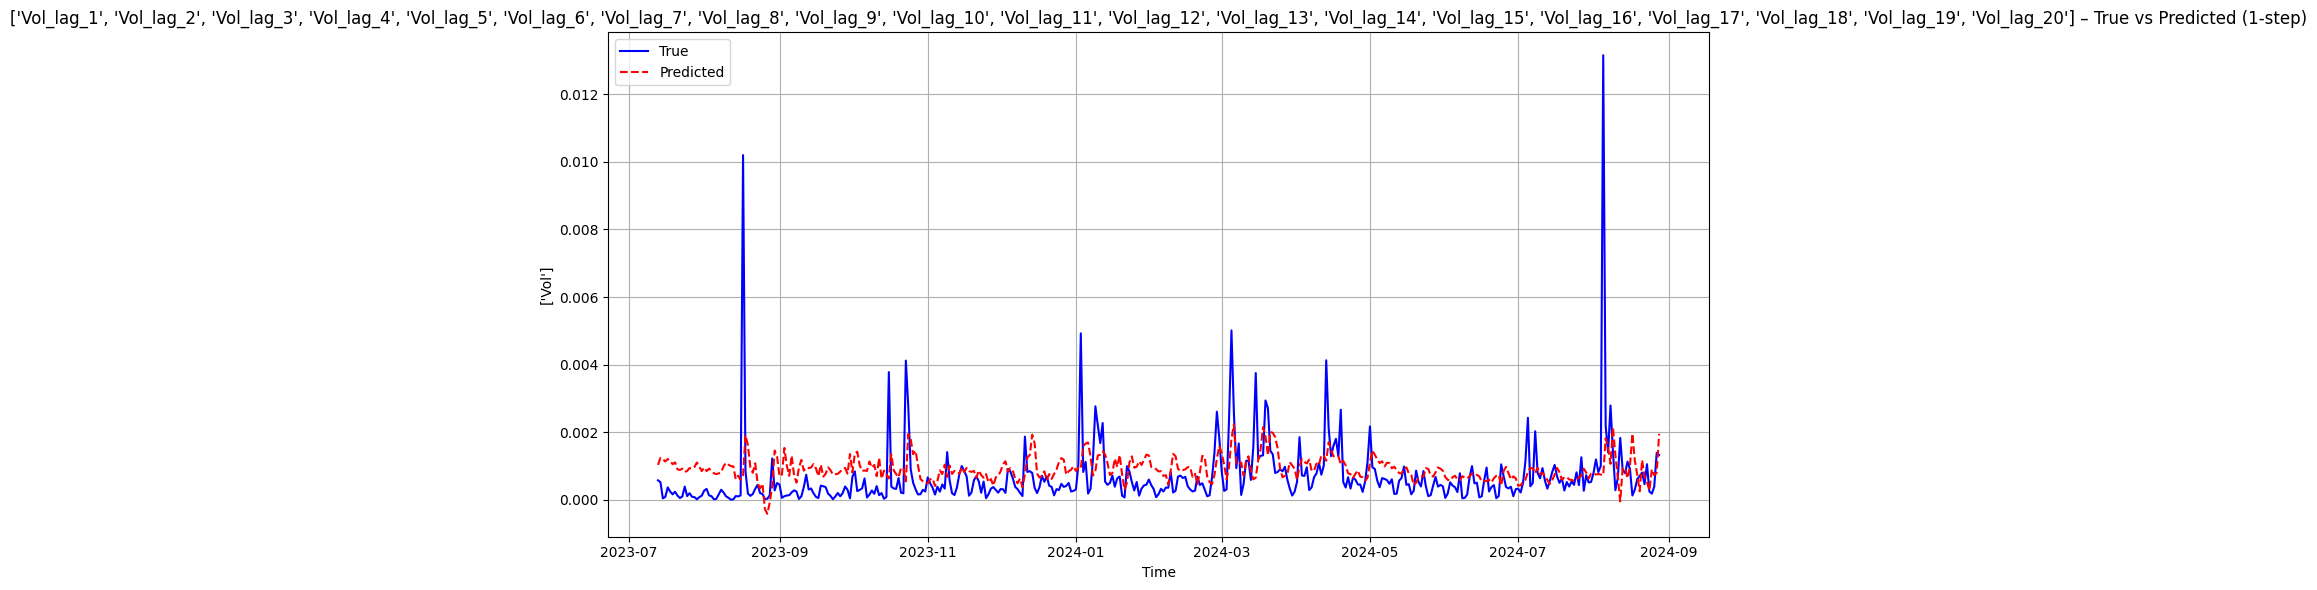


Resultados:
         MSE       MAE      RMSE        MAPE  lags  use_mean_features
0   0.000001  0.000620  0.001069  312.635303     1               True
1   0.000001  0.000620  0.001069  312.633896     2               True
2   0.000001  0.000620  0.001069  312.633681     3               True
3   0.000001  0.000620  0.001069  312.634015     4               True
4   0.000001  0.000619  0.001069  310.965967     5               True
5   0.000001  0.000619  0.001069  310.967731     6               True
6   0.000001  0.000619  0.001069  310.967374     7               True
7   0.000001  0.000619  0.001069  310.967588     8               True
8   0.000001  0.000619  0.001069  310.965371     9               True
9   0.000001  0.000619  0.001070  311.376405    10               True
10  0.000001  0.000619  0.001070  311.376190    11               True
11  0.000001  0.000619  0.001070  311.376357    12               True
12  0.000001  0.000619  0.001070  311.375833    13               True
13  0.0

In [289]:
lags = 20
use_mean = [True, False]

results_list = []
for use in use_mean:
    for lag in range(1, lags + 1):
        print(f"Experimento -> Lags: {lag} | Use Mean Features: {use}")
        metrics_dict = run_experiment(
            df=df,
            repo=repo,
            timestamp_col=TIMESTAMP_COLUMN,
            use_mean_features=use,
            lags=lag,
            train_frac=TRAIN_FRAC,
            valid_frac=VALID_FRAC,
            id_columns=ID_COLUMNS,
            target_col=TARGET_COLUMN,
            context_length=CONTEXT_LENGTH,
            forecast_horizon=FORECAST_HORIZON,
            model=model
        )
        metrics_dict["lags"] = lag
        metrics_dict["use_mean_features"] = use
        results_list.append(metrics_dict)

metrics_df = pd.DataFrame(results_list)
print("\nResultados:")
display(metrics_df)

if len(metrics_df) > 0:
    best = metrics_df.sort_values("RMSE").iloc[0]
    print("\nMelhor combinação:")
    print(best)
